# Imports

In [1]:
!pip install biopython
from Bio.SeqUtils.IsoelectricPoint import IsoelectricPoint as IEP
from Bio.SeqUtils.ProtParam import ProteinAnalysis
from Bio import SeqIO
import re
import pandas as pd
import numpy as np
from scipy.stats import ks_2samp

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
import shap

from Bio import pairwise2

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import seaborn as sns

C:\Users\marts\anaconda3\envs\protein310\lib\site-packages\Bio\pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(


# Databases

## HET-s sequences

'/41598_2015_BFsrep12494_MOESM2_ESM.xls'

In [2]:
file_xls = 'files/data/41598_2015_BFsrep12494_MOESM2_ESM.xls'
hets_data = pd.read_excel(file_xls, engine='xlrd')

In [3]:
# Columns E, J, N with the characters ' ' and '-' removed
col_e = hets_data.iloc[:, 4].astype(str).str.replace('[- ]', '', regex=True).str.upper()
col_j = hets_data.iloc[:, 9].astype(str).str.replace('[- ]', '', regex=True).str.upper()
col_n = hets_data.iloc[:, 13].astype(str).str.replace('[- ]', '', regex=True).str.upper()

seqid_col = hets_data.iloc[:, 0].dropna().astype(str).str.upper()  # kolumna seqid

# combining seqid with every motif
def make_df_with_seqid(seqs, seqid_col):
    seqs = seqs.reset_index(drop=True)
    seqid_col = seqid_col.reset_index(drop=True)
    seqid_repeated = seqid_col.loc[seqid_col.index.repeat(len(seqs)//len(seqid_col))].reset_index(drop=True)
    df = pd.DataFrame({'seqid': seqid_repeated, 'sequence': seqs})
    return df

df_e = make_df_with_seqid(col_e, seqid_col)
df_j = make_df_with_seqid(col_j, seqid_col)
df_n = make_df_with_seqid(col_n, seqid_col)

df_combined = pd.concat([df_e, df_j, df_n], ignore_index=True)

# number of motifs in seqid
df_combined['num'] = df_combined.groupby('seqid').cumcount() + 1

# ID - seqid_nr
#df_combined['num'] = df_combined['num'].astype(int)
df_combined['id'] = (df_combined['seqid'].str.lstrip('>')
                     + '_'
                     + df_combined['num'].astype(str))

# drop Nan
df_combined = df_combined[df_combined['sequence'].notna() & (df_combined['sequence'] != 'NAN')]

# Final DataFrame
df_final = df_combined[['id', 'sequence']]

df_final_unique_hets = df_final.drop_duplicates(subset='sequence').reset_index(drop=True)

print(df_final_unique_hets.count())
print(df_final_unique_hets.head())

id          363
sequence    363
dtype: int64
                           id               sequence
0  GI_171848907_PDB_2RNM_A__1  GRNSAKDIRTEERARVQLGNV
1  GI_228212_PRF__1718317B__1  GRNSAKDIRTEKRARVQLGNV
2  GI_342871650_GB_EGU74155_1  VRIYAKDIKSEEMARVRVGNE
3  GI_342887385_GB_EGU86897_1    GKNSAGRINGPGMVNIGNS
4  GI_347837243_EMB_CCD5181_1  HRIKIGKVTQASNAKAVIGVH


Statistics:
count    363.00
mean      20.85
std        0.52
min       19.00
25%       21.00
50%       21.00
75%       21.00
max       22.00
Name: length, dtype: float64

Number of unique sequences: 363.00
Mean lenght: 20.85
Shortest sequence: 19.00
Longest sequence: 22.00


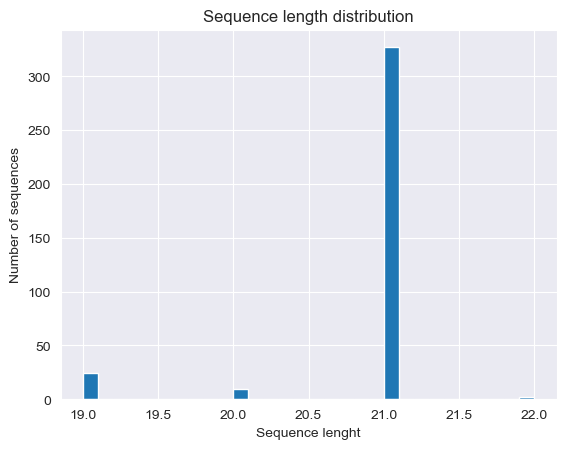

In [4]:
df_final_unique_hets = df_final_unique_hets.dropna(subset=['sequence'])

df_final_unique_hets['length'] = df_final_unique_hets['sequence'].apply(len)
stats = df_final_unique_hets['length'].describe()
print("Statistics:")
print(stats.round(2))

print(f"\nNumber of unique sequences: {df_final_unique_hets['sequence'].nunique():.2f}")
print(f"Mean lenght: {df_final_unique_hets['length'].mean():.2f}")
print(f"Shortest sequence: {df_final_unique_hets['length'].min():.2f}")
print(f"Longest sequence: {df_final_unique_hets['length'].max():.2f}")

import matplotlib.pyplot as plt
plt.hist(df_final_unique_hets['length'], bins=30)
plt.title("Sequence length distribution")
plt.xlabel("Sequence lenght")
plt.ylabel("Number of sequences")
plt.show()

## BASS sequences

'1-s2.0-S0022283620305805-mmc11.xlsx'

In [5]:
bass_file = 'files/data/1-s2.0-S0022283620305805-mmc11.xlsx'
df = pd.read_excel(bass_file)

In [6]:
# Row selection (range 4-300 and 305-353)
df_selected = pd.concat([df.iloc[3:300], df.iloc[304:353]]).reset_index(drop=True)

# Columns I and J from XLSX file with id
col_c = df_selected.iloc[:, 2].dropna().astype(str)  # column C (ID dla I)
col_f = df_selected.iloc[:, 5].dropna().astype(str)  # column F (ID dla J_2)

col_i = df_selected.iloc[:, 8].dropna().astype(str).str.replace('[- ]', '', regex=True).str.upper()  # ccolumn I
col_j_2 = df_selected.iloc[:, 9].dropna().astype(str).str.replace('[- ]', '', regex=True).str.upper() # column J

df_i = pd.DataFrame({'id': col_c, 'sequence': col_i})
df_j_2 = pd.DataFrame({'id': col_f, 'sequence': col_j_2})

df_result = pd.concat([df_i, df_j_2], ignore_index=True)
df_final_unique_bass = df_result.copy()

df_final_unique_bass['id'] = df_final_unique_bass['id'].fillna('').astype(str)

df_final_unique_bass['id'] = df_final_unique_bass['id'] + '_' + df_final_unique_bass.groupby('id').cumcount().add(1).astype(str)

df_final_unique_bass = df_final_unique_bass.drop_duplicates(subset='sequence').reset_index(drop=True)
print(df_final_unique_bass)


               id                            sequence
0    CAB66307.1_1         RHVHLRARASGSARIYQAGRDQHITER
1    ANJ07606.1_1         RDVHLRARASGSARIYQAGRDQHITER
2    OWA03540.1_1           VHLRARASGSARIYQAGRDQHITER
3    PPS88432.1_1         RSVHLRARASGSARIYQAGRDQHITER
4    SEU47809.1_1         GSLVMKAKASGHGRVYQAGRDQTIHER
..            ...                                 ...
506  PSB32049.1_1         GDNRVNISGGNVQGFIQENHGTVTQNF
507  PSM41702.1_1           MNVSGERPIGAESIQVAVSGDSTRV
508  SCG45720.1_1                 FEARDRSTMFNAPDGTINV
509  SCZ16690.1_1              AGAADALAEKLRVRYRRDERWA
510  SHN33320.1_1  PAPTPARSSGESAITVGDVSGILSIGDHNVNLLF

[511 rows x 2 columns]


Statistics:
count    511.00
mean      22.87
std        5.86
min       10.00
25%       20.00
50%       22.00
75%       25.00
max       65.00
Name: length, dtype: float64

Number of unique sequences: 511.00
Mean lenght: 22.87
Shortest sequence: 10.00
Longest sequence: 65.00


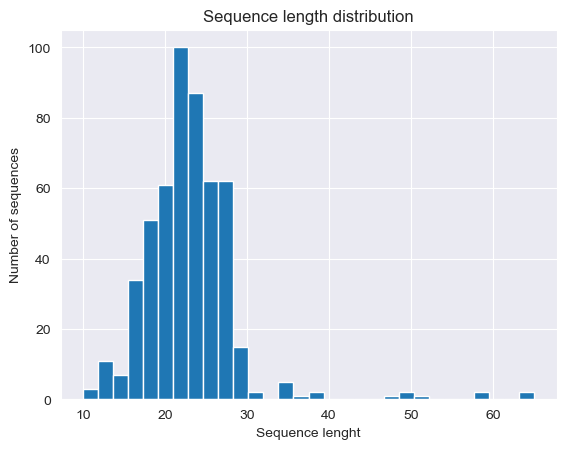

In [7]:
df_final_unique_bass = df_final_unique_bass.dropna(subset=['sequence'])

df_final_unique_bass['length'] = df_final_unique_bass['sequence'].apply(len)
stats = df_final_unique_bass['length'].describe()
print("Statistics:")
print(stats.round(2))

print(f"\nNumber of unique sequences: {df_final_unique_bass['sequence'].nunique():.2f}")
print(f"Mean lenght: {df_final_unique_bass['length'].mean():.2f}")
print(f"Shortest sequence: {df_final_unique_bass['length'].min():.2f}")
print(f"Longest sequence: {df_final_unique_bass['length'].max():.2f}")

import matplotlib.pyplot as plt
plt.hist(df_final_unique_bass['length'], bins=30)
plt.title("Sequence length distribution")
plt.xlabel("Sequence lenght")
plt.ylabel("Number of sequences")
plt.show()

## AmyPro

Varadi M, De Baets G, Vranken WF, Tompa P, Pancsa R. AmyPro: a database of proteins with validated amyloidogenic regions. Nucleic Acids Res. 2018 Jan 4;46(D1):D387-D392. doi: 10.1093/nar/gkx950. PMID: 29040693; PMCID: PMC5753394.

https://www.amypro.net/#!/

In [8]:
fasta_file = 'files/data/amypro.fasta'
records = list(SeqIO.parse(fasta_file, "fasta"))

data = []

for rec in records:
    header = rec.description
    seq = str(rec.seq)
    prot_id = rec.id.split()[0]

    # class
    class_match = re.search(r"class='([^']+)'", header)
    prot_class = class_match.group(1) if class_match else "unknown"

    # regions
    match = re.search(r"regions=\{\s*([^\}]*)\s*\}", header)

    # jif lack of regions all sequence
    if not match:
        data.append({
            "id": f"{prot_id}_full",
            "length": len(seq),
            "sequence": seq,
            "class": prot_class
        })
        continue

    regions_raw = match.group(1)
    region_pairs = re.findall(r"(\d+)-(\d+)", regions_raw)

    motif_num = 1
    for start, end in region_pairs:
        start, end = int(start), int(end)
        fragment = seq[start - 1:end]
        length = len(fragment)

        data.append({
            "id": f"{prot_id}_{motif_num}",
            "length": length,
            "sequence": fragment,
            "class": prot_class
        })
        motif_num += 1

df_amypro = pd.DataFrame(data)
df_amypro_final = df_amypro.drop_duplicates(subset='sequence').reset_index(drop=True)
print(df_amypro_final)

            id  length                                           sequence  \
0    AP00055_1     101  GVFGQNNNQMQINGNNNNSLFGKANTFSNSASGGLFGQNNQQQGSG...   
1    AP00054_1     153  MPPKKFKDLNSFLDDQPKDPNLVASPFGGYFKNPAADAGSNNASKK...   
2    AP00057_1      97  MINPVQQQNQIGYPPTYGQWGQWYGNAQQIGQYVPNGWQVPAYGVY...   
3    AP00056_1      97  QQINSNNNSNSNGPGHKRYYNNRDSNNNRGNYNRRNNNNGNSNRRP...   
4    AP00051_1       6                                             VTVQCI   
..         ...     ...                                                ...   
151  AP00065_1      37              HDEFERHAEGTFTSDVSSYLEGQAAKEFIAWLVKGRG   
152  AP00109_1      11                                        TESYFVFSVGM   
153  AP00108_1      34                 EASNCFAIRHFENKFAVETLICFNLFLNSQEKHY   
154  AP00124_1      32                   AFTCHCRRSCYSTEYSYGTCTVMGINHRFCCL   
155  AP00125_1      38             KQIVYWKQWLSLRNPILVFLKTRVLRQWRLFSKHEWTN   

                  class  
0             not known  
1      functional prion

Statistics:
count    156.00
mean      30.93
std       47.44
min        4.00
25%        9.00
50%       17.00
75%       32.00
max      381.00
Name: length, dtype: float64

Number of unique sequences: 156.00
Mean lenght: 30.93
Shortest sequence: 4.00
Longest sequence: 381.00


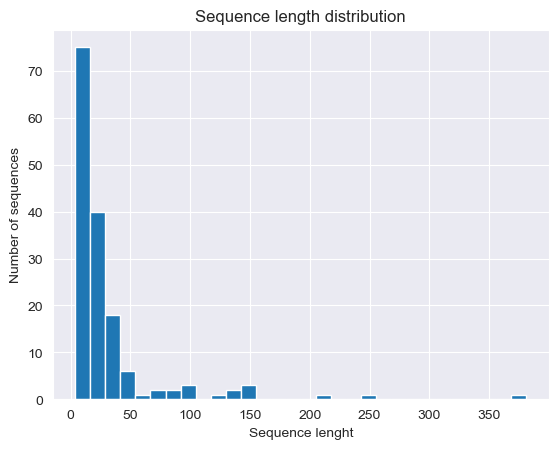

In [9]:
df_amypro_final = df_amypro_final.dropna(subset=['sequence'])

df_amypro_final['length'] = df_amypro_final['sequence'].apply(len)
stats = df_amypro_final['length'].describe()
print("Statistics:")
print(stats.round(2))

print(f"\nNumber of unique sequences: {df_amypro_final['sequence'].nunique():.2f}")
print(f"Mean lenght: {df_amypro_final['length'].mean():.2f}")
print(f"Shortest sequence: {df_amypro_final['length'].min():.2f}")
print(f"Longest sequence: {df_amypro_final['length'].max():.2f}")

import matplotlib.pyplot as plt
plt.hist(df_amypro_final['length'], bins=30)
plt.title("Sequence length distribution")
plt.xlabel("Sequence lenght")
plt.ylabel("Number of sequences")
plt.show()

## AMYpdb

Pawlicki S, Le Béchec A, Delamarche C. AMYPdb: a database dedicated to amyloid precursor proteins. BMC Bioinformatics. 2008 Jun 10;9:273. doi: 10.1186/1471-2105-9-273. PMID: 18544157; PMCID: PMC2442844.

https://amypdb.genouest.org/e107_plugins/amypdb_project/project.php

In [10]:
fasta_file = 'files/data/AMYpdb.fasta'

data = []

for rec in SeqIO.parse(fasta_file, "fasta"):
    seq = str(rec.seq).replace("\n", "").strip()
    prot_id = rec.id

    data.append({
       "id": prot_id.split('|')[0],
       "length": len(seq),
       "sequence": seq
    })

df_amypdb = pd.DataFrame(data)
df_amypdb_final = df_amypdb.drop_duplicates(subset='sequence').reset_index(drop=True)
print(df_amypdb_final)

              id  length                                           sequence
0   A0A2G3_HUMAN      48   VFFGNVDSSGIKHNIFNPPIIARYIRLYPTHYSIRSTLRMELMGCDLN
1   A0A2G6_HUMAN      48   VFFGNVDSSGIKHNIFNPPIIARYIRLHPTHYSIRSTLRMELMGCDLN
2     A0SNU6_PIG      48   TRLSFSKDWSFYLLVHTEFTPNAVDQYSCRVKHVTLDKPKIVKWDRDH
3   A3QP67_SHEEP      35                LSHAEFTPNSKDQYSCRVNHVTLTQPKIVKWDRDL
4     B2MG_CANFA      42         VQHPPKIQVYSRHPAZBGKPBFLBCYVSGFHPXZIZIBLLKB
5   B3VSH6_CAPHI      49  ELEDVTPRAGQILKQTYDKFDTNMRSDDALLKNYGLLSCFRKDLHKTET
6   D0VBK1_PERPL      43        DEDTRLFTLYNLVRCLKRDTHKIDAYFKLLRCREVFKNECFTK
7     D3Y4D2_PIG      37              KCNMATCATQHLANFLDRSRNNLGTIFSPTKVGSNTY
8     FIBG_CANFA      24                           YTATRDNCCILDERFGSYCPTTCG
9   G1MN72_AILME      48   SLDSFRAKRCSNLSTCVLGTYTQDLNKFHTFPQTAIGVGAPGKKRVTA
10    IAPP_CRIGR      37              KCNTATCATQRLANFLVHSNNNLGPVLSPTNVGSNTY
11      IAPP_PIG      32                   NMATCATQHLANFLDRSRNNLGTIFSPTKVGS
12    IAPP_S

Statistics:
count    35.00
mean     42.94
std       7.58
min      24.00
25%      37.50
50%      48.00
75%      48.00
max      50.00
Name: length, dtype: float64

Number of unique sequences: 35.00
Mean lenght: 42.94
Shortest sequence: 24.00
Longest sequence: 50.00


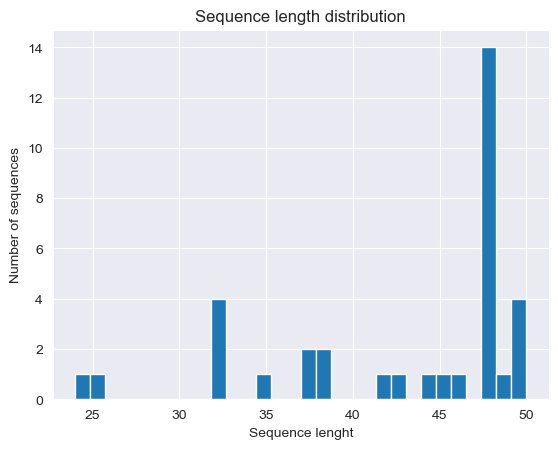

In [11]:
df_amypdb_final = df_amypdb_final.dropna(subset=['sequence'])

df_amypdb_final['length'] = df_amypdb_final['sequence'].apply(len)
stats = df_amypdb_final['length'].describe()
print("Statistics:")
print(stats.round(2))

print(f"\nNumber of unique sequences: {df_amypdb_final['sequence'].nunique():.2f}")
print(f"Mean lenght: {df_amypdb_final['length'].mean():.2f}")
print(f"Shortest sequence: {df_amypdb_final['length'].min():.2f}")
print(f"Longest sequence: {df_amypdb_final['length'].max():.2f}")

import matplotlib.pyplot as plt
plt.hist(df_amypdb_final['length'], bins=30)
plt.title("Sequence length distribution")
plt.xlabel("Sequence lenght")
plt.ylabel("Number of sequences")
plt.show()

## AmyLoad

Wozniak PP, Kotulska M. AmyLoad: website dedicated to amyloidogenic protein fragments. Bioinformatics. 2015 Oct 15;31(20):3395-7. doi: 10.1093/bioinformatics/btv375. Epub 2015 Jun 17. PMID: 26088800.

https://burdukiewicz.com/ramyload/browse.html

In [12]:
amyload = pd.read_csv("files/data/AmyLoad.csv", sep=',')

amyload['PeptideSequence'] = amyload['PeptideSequence'].str.replace(' ', '', regex=False)
amyload['length'] = amyload['PeptideSequence'].str.len()

amyload = amyload[(amyload['length'] <= 50) & (amyload['length'] >= 5)]

amyload['label'] = amyload['FibrilFormation'].map({'Yes': 1, 'No': 0})

df_amyload = amyload.rename(columns={
    'PeptideSequence': 'sequence',
    'Protein': 'protein',
    'AmyLoadIndex': 'id'
})

df_amyload = df_amyload[['id', 'sequence', 'length', 'label']]

df_amyload = df_amyload[df_amyload['label'] == 1]
df_amyload_final = df_amyload[['id', 'sequence', 'length']]

df_amyload_final = df_amyload_final.drop_duplicates(subset='sequence', keep='first').reset_index(drop=True)

print(df_amyload_final)

          id                                     sequence  length
0       AMY1                                PGGGKVQIVYKPV      13
1       AMY9  NLKHQPGGGKVQIVYKPVDLSKVTSKCGSLGNIHHKPGGGQVE      43
2      AMY14                          NLKHQPGGGKVQIVYKEVD      19
3      AMY17                                     GKVQIVYK       8
4      AMY18                                       VQIVYK       6
..       ...                                          ...     ...
433  AMY1482                                      RLVFFAK       7
434  AMY1484                                        LQVVR       5
435  AMY1485                                   IVAGVNYFLD      10
436  AMY1486                                   AFASFQIYAV      10
437  AMY1487                                    ATQRLANFL       9

[438 rows x 3 columns]


## Waltz DB 2.0
Louros, N. et al. (2019) WALTZ-DB 2.0: an updated database containing structural information of experimentally determined amyloid-forming peptides. Nucleic Acids Res, 48 (D1), D389–D393. https://doi.org/10.1093/nar/gkz758

In [13]:
import json
json_file = "files/data/waltzdb_export.json"

with open(json_file, "r") as f:
    raw_data = json.load(f)

df = pd.DataFrame(raw_data)

df['Sequence'] = df['Sequence'].str.replace(" ", "").str.strip()
df['length'] = df['Sequence'].str.len()

df['id'] = df['UniProt ID'].replace("N.A.", pd.NA)

fallback_ids = pd.Series(["WALTZ_" + str(i) for i in df.index], index=df.index)
df['id'] = df['id'].fillna(fallback_ids)

df_waltz = df.rename(columns={
    'Sequence': 'sequence'
})

df_waltz = df_waltz[['id', 'sequence', 'length', 'Classification']]
df_waltz_final = df_waltz.drop_duplicates(subset='sequence').reset_index(drop=True)

df_waltz_final = df_waltz_final[df_waltz_final['Classification'] == 'amyloid'].copy()
df_waltz_final = df_waltz_final.reset_index(drop=True)

df_waltz_final = df_waltz_final[['id', 'sequence', 'length']]
print(df_waltz_final)

             id sequence  length
0        P0ABK7   AAIIGQ       6
1        P02647   AATVYV       6
2        P02766   AEVVFT       6
3        P01034   AGVNYF       6
4        P05067   AIIGLM       6
..          ...      ...     ...
506      P10636   YQIVYK       6
507      Q9UBD5   YQLIWQ       6
508  WALTZ_1409   YTVIIE       6
509      P27986   YVEYIG       6
510      P05453   YYQNYQ       6

[511 rows x 3 columns]


Statistics:
count    511.00
mean       6.00
std        0.04
min        5.00
25%        6.00
50%        6.00
75%        6.00
max        6.00
Name: length, dtype: float64

Number of unique sequences: 511.00
Mean lenght: 6.00
Shortest sequence: 5.00
Longest sequence: 6.00


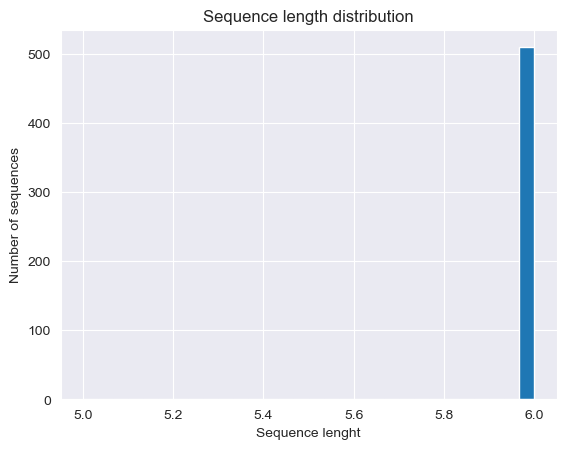

In [14]:
df_waltz_final = df_waltz_final.dropna(subset=['sequence'])

df_waltz_final['length'] = df_waltz_final['sequence'].apply(len)
stats = df_waltz_final['length'].describe()
print("Statistics:")
print(stats.round(2))

print(f"\nNumber of unique sequences: {df_waltz_final['sequence'].nunique():.2f}")
print(f"Mean lenght: {df_waltz_final['length'].mean():.2f}")
print(f"Shortest sequence: {df_waltz_final['length'].min():.2f}")
print(f"Longest sequence: {df_waltz_final['length'].max():.2f}")

import matplotlib.pyplot as plt
plt.hist(df_waltz_final['length'], bins=30)
plt.title("Sequence length distribution")
plt.xlabel("Sequence lenght")
plt.ylabel("Number of sequences")
plt.show()

## CPAD 2.0
Rawat P, Prabakaran R, Sakthivel R, Mary Thangakani A, Kumar S, Gromiha MM. CPAD 2.0: a repository of curated experimental data on aggregating proteins and peptides. Amyloid. 2020 Jun;27(2):128-133. doi: 10.1080/13506129.2020.1715363. Epub 2020 Jan 24. PMID: 31979981.

https://web.iitm.ac.in/bioinfo2/cpad2/peptides/?page=1

In [15]:
cpad_file = "files/data/cpad2.xlsx"
df = pd.read_excel(cpad_file)

df['Peptide'] = df['Peptide'].astype(str).str.replace(" ", "").str.strip()
df['length'] = df['Peptide'].str.len()

df['id'] = df['Uniprot ID'].replace("", pd.NA)

fallback_ids = pd.Series(
    ["CPAD_" + str(i) for i in df.index],
    index=df.index
)

df['id'] = df['id'].fillna(fallback_ids)

df_cpad = df.rename(columns={
    'Peptide': 'sequence'
})

df_cpad = df_cpad[['id', 'sequence', 'length', 'Classification']]
df_cpad = df_cpad.drop_duplicates(subset='sequence').reset_index(drop=True)

df_cpad_final = df_cpad[df_cpad['Classification'] == 'Amyloid'].copy()
df_cpad_final = df_cpad_final.reset_index(drop=True)

df_cpad_final = df_cpad_final[['id', 'sequence', 'length']]
df_cpad_final = df_cpad_final.dropna(subset=['sequence'])

print(df_cpad_final)

            id                                           sequence  length
0       P05067                                                GYE       3
1       CPAD_1                                               KFFE       4
2       CPAD_2                                               KVVE       4
3       P05453                                               NNQQ       4
4       P10997                                              AILSS       5
..         ...                                                ...     ...
711  CPAD_2026  GQGGGTHNQWNKPSKPKTNMKHMAGAAAAGAVVGGLGGYMLGSAMS...      56
712     P04156  GQPHGGGWGQGGGTHSQWNKPSKPKTNMKHMAGAAAAGAVVGGLGG...      65
713  CPAD_2028  MATLEKLMKAFESLKSFQQQQQQQQQQQQQQQQQQQQQQQQQQQQQ...      71
714     P37840  GKTKEGVLYVGSKTKEGVVHGVATVAEKTKEQVTNVGGAVVTGVTA...      79
715     P02655  DEPPQSPWDRVKDLATVYVDVLKDSRRDYVSQFEGSALGKQLNLKL...      83

[716 rows x 3 columns]


Statistics:
count    716.00
mean      13.19
std       11.48
min        3.00
25%        6.00
50%        7.00
75%       16.00
max       83.00
Name: length, dtype: float64

Number of unique sequences: 716
Mean length: 13.19
Shortest sequence: 3
Longest sequence: 83


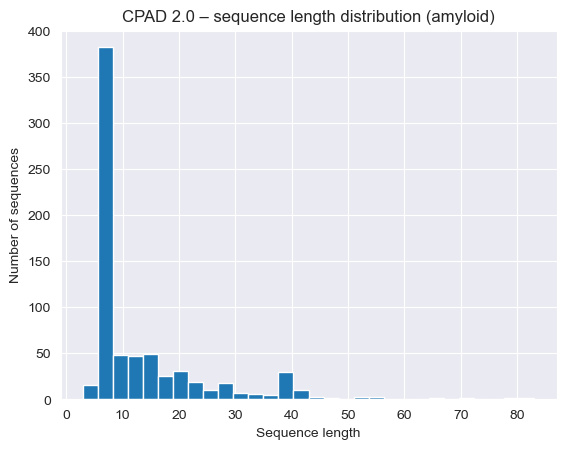

In [16]:
stats = df_cpad_final['length'].describe()
print("Statistics:")
print(stats.round(2))

print(f"\nNumber of unique sequences: {df_cpad_final['sequence'].nunique()}")
print(f"Mean length: {df_cpad_final['length'].mean():.2f}")
print(f"Shortest sequence: {df_cpad_final['length'].min()}")
print(f"Longest sequence: {df_cpad_final['length'].max()}")

plt.hist(df_cpad_final['length'], bins=30)
plt.title("CPAD 2.0 – sequence length distribution (amyloid)")
plt.xlabel("Sequence length")
plt.ylabel("Number of sequences")
plt.show()

# Combined

In [17]:
df_combined = pd.concat([df_final_unique_hets,
                         df_final_unique_bass,
                         df_amypro_final,
                         df_amypdb_final,
                         df_amyload_final,
                         df_waltz_final,
                         df_cpad_final],
                        ignore_index=True)

if 'length' not in df_combined.columns:
    df_combined['length'] = df_combined['sequence'].str.len()

df_combined_filtered = df_combined[
    (df_combined['length'] >= 5) &
    (df_combined['length'] <= 50)
].copy()

df_combined_filtered.reset_index(drop=True, inplace=True)
df_combined_filtered_final = df_combined_filtered.drop_duplicates(subset='sequence').reset_index(drop=True)
print(df_combined_filtered_final.head())

                           id               sequence  length class
0  GI_171848907_PDB_2RNM_A__1  GRNSAKDIRTEERARVQLGNV      21   NaN
1  GI_228212_PRF__1718317B__1  GRNSAKDIRTEKRARVQLGNV      21   NaN
2  GI_342871650_GB_EGU74155_1  VRIYAKDIKSEEMARVRVGNE      21   NaN
3  GI_342887385_GB_EGU86897_1    GKNSAGRINGPGMVNIGNS      19   NaN
4  GI_347837243_EMB_CCD5181_1  HRIKIGKVTQASNAKAVIGVH      21   NaN


Statistics:
count    1913.00
mean       17.03
std         9.70
min         5.00
25%         6.00
50%        19.00
75%        22.00
max        50.00
Name: length, dtype: float64

Number of unique sequences: 1913.00
Mean lenght: 17.03
Shortest sequence: 5.00
Longest sequence: 50.00


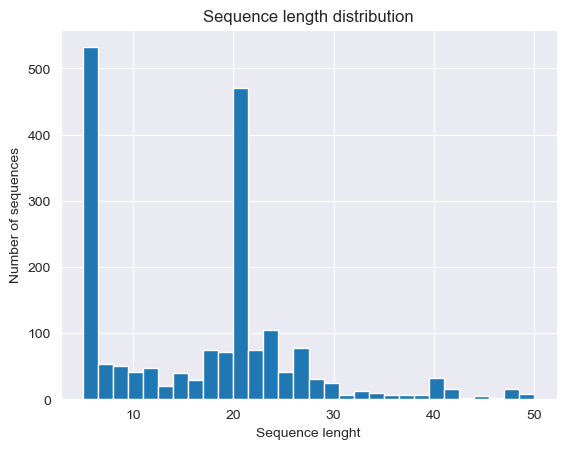

In [18]:
df_combined_filtered_final = df_combined_filtered_final.dropna(subset=['sequence'])

df_combined_filtered_final['length'] = df_combined_filtered_final['sequence'].apply(len)
stats = df_combined_filtered_final['length'].describe()
print("Statistics:")
print(stats.round(2))

print(f"\nNumber of unique sequences: {df_combined_filtered_final['sequence'].nunique():.2f}")
print(f"Mean lenght: {df_combined_filtered_final['length'].mean():.2f}")
print(f"Shortest sequence: {df_combined_filtered_final['length'].min():.2f}")
print(f"Longest sequence: {df_combined_filtered_final['length'].max():.2f}")

import matplotlib.pyplot as plt
plt.hist(df_combined_filtered_final['length'], bins=30)
plt.title("Sequence length distribution")
plt.xlabel("Sequence lenght")
plt.ylabel("Number of sequences")
plt.show()

## Redundancy

In [19]:
def identity(seq1, seq2):
    alignments = pairwise2.align.globalxx(seq1, seq2, one_alignment_only=True)
    aln = alignments[0]
    matches = sum([1 if a==b else 0 for a,b in zip(aln.seqA, aln.seqB)])
    return matches / max(len(seq1), len(seq2))

def remove_redundant(df, threshold=0.7):
    sequences = []
    ids = []
    lengths = []

    for i, row in df.iterrows():
        seq = row['sequence']
        redundant = False
        for s in sequences:
            if identity(seq, s) >= threshold:
                redundant = True
                break
        if not redundant:
            sequences.append(seq)
            ids.append(row['id'])
            lengths.append(len(seq))

    return pd.DataFrame({
        'id': ids,
        'sequence': sequences,
        'length': lengths
    })

df_nonredundant = remove_redundant(df_combined_filtered_final, threshold=0.7)
df_nonredundant.reset_index(drop=True, inplace=True)
print(df_nonredundant.head())

                           id               sequence  length
0  GI_171848907_PDB_2RNM_A__1  GRNSAKDIRTEERARVQLGNV      21
1  GI_342871650_GB_EGU74155_1  VRIYAKDIKSEEMARVRVGNE      21
2  GI_342887385_GB_EGU86897_1    GKNSAGRINGPGMVNIGNS      19
3  GI_347837243_EMB_CCD5181_1  HRIKIGKVTQASNAKAVIGVH      21
4  GI_475677570_GB_EMT74561_1  VRNYASEIKGDEDAKVRLGND      21


In [20]:
print("Unique id in df_seq:", df_nonredundant['id'].nunique())

Unique id in df_seq: 1023


In [21]:
df_nonredundant['id'] = df_nonredundant['id'].fillna('').astype(str)

df_nonredundant['id'] = (
    df_nonredundant['id']
    + '_'
    + (df_nonredundant.groupby('id').cumcount() + 1).astype(str)
)

print("Unique ID:", df_nonredundant['id'].nunique())
print("All:", len(df_nonredundant))

Unique ID: 1054
All: 1054


Statistics:
count    1054.00
mean       17.37
std         9.14
min         5.00
25%         7.00
50%        20.00
75%        21.00
max        50.00
Name: length, dtype: float64

Number of unique sequences: 1054.00
Mean lenght: 17.37
Shortest sequence: 5.00
Longest sequence: 50.00


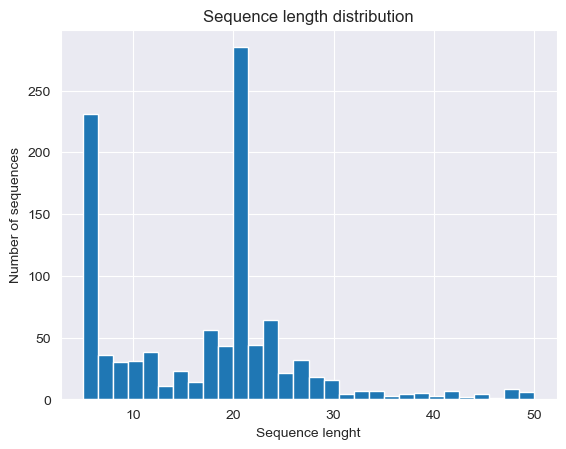

In [22]:
df_nonredundant = df_nonredundant.dropna(subset=['sequence'])

df_nonredundant['length'] = df_nonredundant['sequence'].apply(len)
stats = df_nonredundant['length'].describe()
print("Statistics:")
print(stats.round(2))

print(f"\nNumber of unique sequences: {df_nonredundant['sequence'].nunique():.2f}")
print(f"Mean lenght: {df_nonredundant['length'].mean():.2f}")
print(f"Shortest sequence: {df_nonredundant['length'].min():.2f}")
print(f"Longest sequence: {df_nonredundant['length'].max():.2f}")

import matplotlib.pyplot as plt
plt.hist(df_nonredundant['length'], bins=30)
plt.title("Sequence length distribution")
plt.xlabel("Sequence lenght")
plt.ylabel("Number of sequences")
plt.show()

In [23]:
fasta_out = "files/df_nonredundant.fasta"

valid_aas = set("ACDEFGHIKLMNPQRSTVWY")

skipped = []

with open(fasta_out, "w") as f:
    for _, row in df_nonredundant.iterrows():
        seq_id = str(row['id'])
        seq = str(row['sequence']).upper()

        if not set(seq).issubset(valid_aas):
            skipped.append(seq_id)
            continue

        f.write(f">{seq_id}\n")
        f.write(f"{seq}\n")

print(f"Skipped sequences: {len(skipped)}")

Skipped sequences: 4


# Features selection

## Aggrescan

In [24]:
agg_file = 'files/aggrescan_output.txt'

agg_data = []
with open(agg_file) as f:
    for line in f:
        line = line.strip()
        if not line or line.startswith("#"):
            continue
        if not (line[0].isdigit() or line[0] == '-'):
            continue

        cols = line.split()
        if len(cols) < 13:
            continue

        agg_data.append({
            "a3vSA": float(cols[0]),
            "id": cols[1].replace(">",""),
            "AAT": float(cols[5]),
            "Na4vSS": float(cols[7]),
            "THSA": float(cols[9]),
            "nHS": int(cols[11]),
            "TA": float(cols[12]),
        })


df_agg = pd.DataFrame(agg_data)
print(df_agg)

      a3vSA                            id     AAT  Na4vSS    THSA  nHS  \
0    -0.457  GI_171848907_PDB_2RNM_A__1_1   0.190  -0.494   0.190    1   
1    -0.160  GI_342871650_GB_EGU74155_1_1   2.140  -0.165   1.871    1   
2    -0.256  GI_342887385_GB_EGU86897_1_1   1.438  -0.256   1.438    1   
3    -0.001  GI_347837243_EMB_CCD5181_1_1   4.054  -0.008   4.054    2   
4    -0.436  GI_475677570_GB_EMT74561_1_1   0.570  -0.435   0.000    0   
...     ...                           ...     ...     ...     ...  ...   
1027  0.083                      P01034_2   6.689   0.032   6.689    2   
1028 -0.047                   CPAD_1978_1   7.260  -0.093   6.547    2   
1029  0.076                      P05067_4  13.961   0.075  13.839    2   
1030  0.166                   CPAD_2019_1  12.642   0.138   9.792    2   
1031 -1.206                   CPAD_2021_1   0.000  -1.216   0.000    0   

             TA  
0     -9.478301  
1     -2.956500  
2     -3.895801  
3      0.459500  
4     -8.256500  
...

## Rest of features

In [25]:
fasta_file = 'files/df_nonredundant.fasta'

records = list(SeqIO.parse(fasta_file, "fasta"))

seq_data = []
for rec in records:
    seq_clean = re.sub(r'[^ACDEFGHIKLMNPQRSTVWY]', '', str(rec.seq).upper())
    seq_data.append({
        'id': rec.id,
        'sequence': seq_clean,
        'length': len(seq_clean)
    })

df_seq = pd.DataFrame(seq_data)
print("FASTA loaded:", df_seq.shape)

FASTA loaded: (1050, 3)


In [26]:
aa_groups = {
    "polar": "NQSTY",
    "nonpolar": "ACFGILMPVW",
    "acidic": "DE",
    "basic": "HKR",
}

def aa_fraction(seq, aas):
    return sum(seq.count(a) for a in aas) / len(seq) if len(seq) > 0 else 0

for group, letters in aa_groups.items():
    df_seq[group+"_fraction"] = df_seq['sequence'].apply(lambda s: aa_fraction(s, letters))

# Net charge: +1 for K/R, -1 for D/E, H=+0.1
def net_charge(seq):
    charge = seq.count('K') + seq.count('R') - seq.count('D') - seq.count('E') + 0.1*seq.count('H')
    return charge

df_seq['net_charge'] = df_seq['sequence'].apply(net_charge)

In [27]:
# Hydrophobicity (Kyte-Doolittle scale)
hydro_scale = {
    'A':1.8,'C':2.5,'D':-3.5,'E':-3.5,'F':2.8,'G':-0.4,'H':-3.2,'I':4.5,
    'K':-3.9,'L':3.8,'M':1.9,'N':-3.5,'P':-1.6,'Q':-3.5,'R':-4.5,'S':-0.8,
    'T':-0.7,'V':4.2,'W':-0.9,'Y':-1.3
}
df_seq['hydrophobicity'] = df_seq['sequence'].apply(lambda s: sum(hydro_scale[a] for a in s)/len(s) if len(s)>0 else 0)

## Merge

In [28]:
df_final = df_seq.merge(df_agg, on="id", how="left")
df_final = df_final.dropna()
print("Final dataframe:", df_final.shape)
df_final.head(20)

Final dataframe: (1034, 15)


,id,sequence,length,polar_fraction,nonpolar_fraction,acidic_fraction,basic_fraction,net_charge,hydrophobicity,a3vSA,AAT,Na4vSS,THSA,nHS,TA
0,GI_171848907_PDB_2RNM_A__1_1,GRNSAKDIRTEERARVQLGNV,21,0.238095,0.380952,0.142857,0.238095,2.0,-1.185714,-0.457,0.190,-0.494,0.190,1.0,-9.478301
1,GI_342871650_GB_EGU74155_1_1,VRIYAKDIKSEEMARVRVGNE,21,0.142857,0.428571,0.190476,0.238095,1.0,-0.676190,-0.160,2.140,-0.165,1.871,1.0,-2.956500
2,GI_342887385_GB_EGU86897_1_1,GKNSAGRINGPGMVNIGNS,19,0.315789,0.578947,0.000000,0.105263,2.0,-0.563158,-0.256,1.438,-0.256,1.438,1.0,-3.895801
3,GI_347837243_EMB_CCD5181_1_1,HRIKIGKVTQASNAKAVIGVH,21,0.190476,0.523810,0.000000,0.285714,4.2,-0.019048,-0.001,4.054,-0.008,4.054,2.0,0.459500
4,GI_475677570_GB_EMT74561_1_1,VRNYASEIKGDEDAKVRLGND,21,0.190476,0.380952,0.238095,0.190476,-1.0,-1.138095,-0.436,0.570,-0.435,0.000,0.0,-8.256500
5,GI_584417796_EMB_CDM2951_1_1,RGQRITDVEMSGKGKALVGRV,21,0.142857,0.523810,0.095238,0.238095,3.0,-0.490476,-0.181,1.782,-0.219,1.631,1.0,-3.641200
6,GI_587682067_GB_EWZ28672_1_1,SSNTIDQAKVAETAKVKVVNE,21,0.333333,0.380952,0.142857,0.142857,0.0,-0.428571,-0.195,1.422,-0.186,0.000,0.0,-3.070600
7,GI_587689594_GB_EWZ36199_1_1,AAQRISAVCATEESTTLAGKF,21,0.285714,0.523810,0.095238,0.095238,0.0,0.180952,-0.041,2.716,-0.128,2.085,1.0,-1.784600
8,GI_587730734_GB_EXA28450_1_1,GMNSAGNVKTEDLARFQLGNV,21,0.285714,0.523810,0.095238,0.095238,0.0,-0.371429,-0.194,0.456,-0.252,0.456,1.0,-4.606300
9,GI_591409972_GB_EXL45109_1_1,GINRIYKAKVTETAKVKVGNE,21,0.238095,0.428571,0.095238,0.238095,3.0,-0.590476,-0.108,1.768,-0.124,0.000,0.0,-1.643100


# SHAP

## Non-amyloidic set for SHAP

### Waltz DB 2.0

In [29]:
df_waltz_non_amyloid = df_waltz.drop_duplicates(subset='sequence').reset_index(drop=True)

df_waltz_non_amyloid = df_waltz_non_amyloid[df_waltz_non_amyloid['Classification'] == 'non-amyloid'].copy()
df_waltz_non_amyloid = df_waltz_non_amyloid.reset_index(drop=True)

df_waltz_non_amyloid = df_waltz_non_amyloid[['id', 'sequence', 'length']]
print(df_waltz_non_amyloid)

             id sequence  length
0        Q13148   AAAQAA       6
1       WALTZ_1   AAELRN       6
2        P35637   AAIDWF       6
3        Q13148   AAIGWG       6
4        Q13148   AALQSS       6
..          ...      ...     ...
887  WALTZ_1407   YTFTIS       6
888      Q08925   YTNISN       6
889      P61769   YVSGFH       6
890      P32831   YYNYNN       6
891      P61769   YYTEFT       6

[892 rows x 3 columns]


### CPAD 2.0

In [30]:
df_cpad = df_cpad[['id', 'sequence', 'length', 'Classification']]
df_cpad = df_cpad.drop_duplicates(subset='sequence').reset_index(drop=True)

df_cpad_non_amyloids = df_cpad[df_cpad['Classification'] == 'Non-amyloid'].copy()
df_cpad_non_amyloids = df_cpad_non_amyloids.reset_index(drop=True)

df_cpad_non_amyloids = df_cpad_non_amyloids[['id', 'sequence', 'length']]
df_cpad_non_amyloids = df_cpad_non_amyloids.dropna(subset=['sequence'])

print(df_cpad_non_amyloids)

           id                              sequence  length
0      P10636                                  VKSE       4
1      P00287                                 APGET       5
2      P05067                                 KLVFF       5
3      P02247                                 RDNSA       5
4      P00287                                 SEFSV       5
...       ...                                   ...     ...
1050  P80031           DQKEAALVDMVNDGVEDLRCKYATLIYT      28
1051   P10636        VKSEKLDFKDRVQSKIGSLDNITHVPGGGN      30
1052   P47929   FHVNLLCGEEQGSDAALHFNPRLDTSEVVFNSKEQ      35
1053   P10636  KPVDLSKVTSKCGSLGNIHHKPGGGQVEVKSEKLDF      36
1054   P10636  QTAPVPMPDLKNVKSKIGSTENLKHQPGGGKVQIVY      36

[1055 rows x 3 columns]


### HET-s sequences

In [31]:
file_xls = 'files/data/41598_2015_BFsrep12494_MOESM2_ESM.xls'
hets_data = pd.read_excel(file_xls, engine='xlrd')

In [32]:
col_before = hets_data.iloc[:, 3].astype(str).str.replace('[- ]', '', regex=True).str.upper()
col_loop   = hets_data.iloc[:, 7].astype(str).str.replace('[- ]', '', regex=True).str.upper()
col_after  = hets_data.iloc[:, 12].astype(str).str.replace('[- ]', '', regex=True).str.upper()

# seqid
seqid_col = hets_data.iloc[:, 0].dropna().astype(str).str.upper()

In [33]:
def make_df_with_seqid(seqs, seqid_col, region_name):
    seqs = seqs.reset_index(drop=True)
    seqid_col = seqid_col.reset_index(drop=True)

    seqid_repeated = seqid_col.loc[
        seqid_col.index.repeat(len(seqs) // len(seqid_col))
    ].reset_index(drop=True)

    df = pd.DataFrame({
        'seqid': seqid_repeated,
        'sequence': seqs,
        'region': region_name,
        'class': 'non-amyloid'
    })
    return df

df_before = make_df_with_seqid(col_before, seqid_col, 'before_motif')
df_loop   = make_df_with_seqid(col_loop,   seqid_col, 'loop')
df_after  = make_df_with_seqid(col_after,  seqid_col, 'after_motif')

df_hets_non_amyloids = pd.concat(
    [df_before, df_loop, df_after],
    ignore_index=True
)

df_hets_non_amyloids['num'] = df_hets_non_amyloids.groupby('seqid').cumcount() + 1

df_hets_non_amyloids['id'] = (
    df_hets_non_amyloids['seqid'].str.lstrip('>')
    + '_NON_'
    + df_hets_non_amyloids['num'].astype(str)
)


df_hets_non_amyloids = df_hets_non_amyloids[
    df_hets_non_amyloids['sequence'].notna() &
    (df_hets_non_amyloids['sequence'] != 'NAN') &
    (df_hets_non_amyloids['sequence'] != '')
]

df_hets_non_amyloids = df_hets_non_amyloids[['id', 'sequence', 'region', 'class']]

df_hets_non_amyloids = df_hets_non_amyloids.drop_duplicates(
    subset='sequence'
).reset_index(drop=True)

df_hets_non_amyloids['length'] = df_hets_non_amyloids['sequence'].apply(len)

print(df_hets_non_amyloids)

                                 id               sequence        region  \
0    GI_171848907_PDB_2RNM_A__NON_1                MKIDAIV  before_motif   
1    GI_228211_PRF__1718317A__NON_1         AMSDAAAQKIDAIV  before_motif   
2    GI_342871650_GB_EGU74155_NON_1        SVLSEAVARKTEWIA  before_motif   
3    GI_342887385_GB_EGU86897_NON_1      VDPVLSDASKNKSLEIA  before_motif   
4    GI_347837243_EMB_CCD5181_NON_1  PQETQEIFEKTWKQALAEIAS  before_motif   
..                              ...                    ...           ...   
365  JGI_TRIVIGV29_8_2_28501__NON_3              YGGKGVWDN   after_motif   
366  JGI_VERAL1_4557_VDBG_018_NON_3           KGVDFNSLFSKR   after_motif   
367  JGI_VEREN1_621292_ESTEXT_NON_3              YGGKDFWDE   after_motif   
368  JGI_WESOR1_271730_CE2717_NON_3              IGVKKSFLD   after_motif   
369  JGI_WESOR1_504224_ESTEXT_NON_3             SSDGLKDFWA   after_motif   

           class  length  
0    non-amyloid       7  
1    non-amyloid      14  
2    n

### UniProt

In [34]:
fasta_file = "files/data/uniprotkb_reviewed_true_AND_length_7_TO_2026_01_25.fasta"

records = list(SeqIO.parse(fasta_file, "fasta"))

data = []
for rec in records:
    data.append({
        "id": rec.id,
        "sequence": str(rec.seq).upper()
    })

df_uniprot = pd.DataFrame(data)

df_uniprot['length'] = df_uniprot['sequence'].apply(len)

df_uniprot = (
    df_uniprot
    .dropna(subset=['sequence'])
    .drop_duplicates(subset='sequence')
    .reset_index(drop=True)
)

print("UniProt non-amyloid:", df_uniprot.shape)

UniProt non-amyloid: (8221, 3)


### Combined (without UniProt - non prioryty)

In [35]:
df_combined_non_amyloids = pd.concat([df_cpad_non_amyloids,
                                      df_waltz_non_amyloid,
                                      df_hets_non_amyloids],
                        ignore_index=True)

if 'length' not in df_combined_non_amyloids.columns:
    df_combined_non_amyloids['length'] = df_combined_non_amyloids['sequence'].str.len()

df_combined_non_amyloids = df_combined_non_amyloids[
    (df_combined_non_amyloids['length'] >= 5) &
    (df_combined_non_amyloids['length'] <= 50)
].copy()

df_combined_non_amyloids.reset_index(drop=True, inplace=True)
df_combined_non_amyloids_final = df_combined_non_amyloids.drop_duplicates(subset='sequence').reset_index(drop=True)
print(df_combined_non_amyloids_final)

                                  id      sequence  length       region  \
0                             P00287         APGET       5          NaN   
1                             P05067         KLVFF       5          NaN   
2                             P02247         RDNSA       5          NaN   
3                             P00287         SEFSV       5          NaN   
4                             Q13148        AAAQAA       6          NaN   
...                              ...           ...     ...          ...   
1469  JGI_TRIVIGV29_8_2_28501__NON_3     YGGKGVWDN       9  after_motif   
1470  JGI_VERAL1_4557_VDBG_018_NON_3  KGVDFNSLFSKR      12  after_motif   
1471  JGI_VEREN1_621292_ESTEXT_NON_3     YGGKDFWDE       9  after_motif   
1472  JGI_WESOR1_271730_CE2717_NON_3     IGVKKSFLD       9  after_motif   
1473  JGI_WESOR1_504224_ESTEXT_NON_3    SSDGLKDFWA      10  after_motif   

            class  
0             NaN  
1             NaN  
2             NaN  
3             NaN  

Statistics:
count    1474.00
mean        8.86
std         5.03
min         5.00
25%         6.00
50%         6.00
75%        10.00
max        36.00
Name: length, dtype: float64

Number of unique sequences: 1474.00
Mean lenght: 8.86
Shortest sequence: 5.00
Longest sequence: 36.00


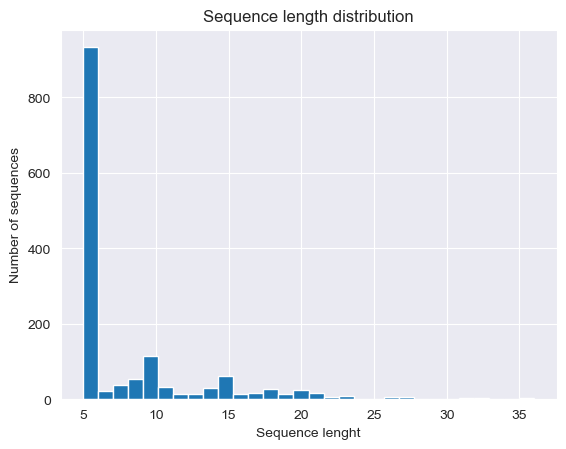

In [36]:
df_combined_non_amyloids_final = df_combined_non_amyloids_final.dropna(subset=['sequence'])

df_combined_non_amyloids_final['length'] = df_combined_non_amyloids_final['sequence'].apply(len)
stats = df_combined_non_amyloids_final['length'].describe()
print("Statistics:")
print(stats.round(2))

print(f"\nNumber of unique sequences: {df_combined_non_amyloids_final['sequence'].nunique():.2f}")
print(f"Mean lenght: {df_combined_non_amyloids_final['length'].mean():.2f}")
print(f"Shortest sequence: {df_combined_non_amyloids_final['length'].min():.2f}")
print(f"Longest sequence: {df_combined_non_amyloids_final['length'].max():.2f}")

import matplotlib.pyplot as plt
plt.hist(df_combined_non_amyloids_final['length'], bins=30)
plt.title("Sequence length distribution")
plt.xlabel("Sequence lenght")
plt.ylabel("Number of sequences")
plt.show()

In [37]:
df_combined_non_amyloids_final = df_combined_non_amyloids_final.copy()

df_combined_non_amyloids_final['id'] = (
    df_combined_non_amyloids_final['id']
    + '_'
    + (df_combined_non_amyloids_final
       .groupby('id')
       .cumcount() + 1
      ).astype(str)
)

df_combined_non_amyloids_final['id'] = (
    df_combined_non_amyloids_final['id']
    .str.replace('_1$', '', regex=True)
)

In [38]:
print("Unique IDs:", df_combined_non_amyloids_final['id'].is_unique)

Unique IDs: True


## Selection of non-amyloids for similar distribution

Checking how many seqences must be added/deleted from combined set to match the distribution

In [39]:
df_amy = df_nonredundant.copy()
df_amy['length'] = df_amy['sequence'].apply(len)

bins = list(range(4, 50, 1))

amy_counts = (
    pd.cut(df_amy['length'], bins=bins)
    .value_counts()
    .sort_index()
)

print(amy_counts)

length
(4, 5]        8
(5, 6]      223
(6, 7]       36
(7, 8]       15
(8, 9]       15
(9, 10]      31
(10, 11]     18
(11, 12]     20
(12, 13]     11
(13, 14]     13
(14, 15]     10
(15, 16]     14
(16, 17]     28
(17, 18]     28
(18, 19]     43
(19, 20]     42
(20, 21]    243
(21, 22]     44
(22, 23]     41
(23, 24]     23
(24, 25]     21
(25, 26]     20
(26, 27]     12
(27, 28]     18
(28, 29]     13
(29, 30]      3
(30, 31]      4
(31, 32]      5
(32, 33]      2
(33, 34]      7
(34, 35]      1
(35, 36]      2
(36, 37]      4
(37, 38]      4
(38, 39]      1
(39, 40]      3
(40, 41]      2
(41, 42]      5
(42, 43]      2
(43, 44]      2
(44, 45]      2
(45, 46]      1
(46, 47]      0
(47, 48]      8
(48, 49]      4
Name: count, dtype: int64


In [40]:
non_counts = (
    pd.cut(df_combined_non_amyloids_final['length'], bins=bins)
    .value_counts()
    .sort_index()
)

print(non_counts)

length
(4, 5]        5
(5, 6]      928
(6, 7]       21
(7, 8]       39
(8, 9]       55
(9, 10]     115
(10, 11]     33
(11, 12]     14
(12, 13]     13
(13, 14]     30
(14, 15]     61
(15, 16]     15
(16, 17]     18
(17, 18]     27
(18, 19]     14
(19, 20]     26
(20, 21]     16
(21, 22]      7
(22, 23]     10
(23, 24]      2
(24, 25]      2
(25, 26]      5
(26, 27]      5
(27, 28]      1
(28, 29]      0
(29, 30]      1
(30, 31]      3
(31, 32]      3
(32, 33]      2
(33, 34]      0
(34, 35]      1
(35, 36]      2
(36, 37]      0
(37, 38]      0
(38, 39]      0
(39, 40]      0
(40, 41]      0
(41, 42]      0
(42, 43]      0
(43, 44]      0
(44, 45]      0
(45, 46]      0
(46, 47]      0
(47, 48]      0
(48, 49]      0
Name: count, dtype: int64


In [41]:
missing = amy_counts - non_counts
missing = missing.clip(lower=0)

print("To be completed:")
print(missing)

To be completed:
length
(4, 5]        3
(5, 6]        0
(6, 7]       15
(7, 8]        0
(8, 9]        0
(9, 10]       0
(10, 11]      0
(11, 12]      6
(12, 13]      0
(13, 14]      0
(14, 15]      0
(15, 16]      0
(16, 17]     10
(17, 18]      1
(18, 19]     29
(19, 20]     16
(20, 21]    227
(21, 22]     37
(22, 23]     31
(23, 24]     21
(24, 25]     19
(25, 26]     15
(26, 27]      7
(27, 28]     17
(28, 29]     13
(29, 30]      2
(30, 31]      1
(31, 32]      2
(32, 33]      0
(33, 34]      7
(34, 35]      0
(35, 36]      0
(36, 37]      4
(37, 38]      4
(38, 39]      1
(39, 40]      3
(40, 41]      2
(41, 42]      5
(42, 43]      2
(43, 44]      2
(44, 45]      2
(45, 46]      1
(46, 47]      0
(47, 48]      8
(48, 49]      4
Name: count, dtype: int64


Removing excess lengths

In [42]:
amy_bins = (
    df_amy
    .groupby(pd.cut(df_amy['length'], bins=bins))
    .size()
)

non_bins = (
    df_combined_non_amyloids_final
    .groupby(pd.cut(df_combined_non_amyloids_final['length'], bins=bins))
    .size()
)

non_trimmed = []

for length_bin, amy_count in amy_bins.items():
    if pd.isna(length_bin) or amy_count == 0:
        continue

    candidates = df_combined_non_amyloids_final[
        pd.cut(df_combined_non_amyloids_final['length'], bins=bins) == length_bin
    ]

    if len(candidates) == 0:
        continue

    sampled = candidates.sample(
        n=min(len(candidates), amy_count),
        random_state=42
    )

    non_trimmed.append(sampled)

df_non_trimmed = pd.concat(non_trimmed).reset_index(drop=True)

C:\Users\marts\AppData\Local\Temp\ipykernel_51676\2754137421.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(pd.cut(df_amy['length'], bins=bins))
C:\Users\marts\AppData\Local\Temp\ipykernel_51676\2754137421.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(pd.cut(df_combined_non_amyloids_final['length'], bins=bins))


Filling in the missing lengths

In [43]:
valid_aa = re.compile(r'^[ACDEFGHIKLMNPQRSTVWY]+$')

def is_valid_sequence(seq):
    return (
        isinstance(seq, str)
        and len(seq) > 0
        and valid_aa.match(seq) is not None
    )

In [44]:
priority_ids = set(df_non_trimmed['id'])
priority_seqs = set(df_non_trimmed['sequence'])

selected_uniprot = []
used_ids = set(priority_ids)
used_seqs = set(priority_seqs)

rng = np.random.default_rng(42)

for length_bin, n_missing in missing.items():
    if n_missing <= 0:
        continue

    low, high = length_bin.left, length_bin.right

    candidates = df_uniprot[
        (df_uniprot['length'] > low) &
        (df_uniprot['length'] <= high)
    ].copy()

    candidates = candidates[
        candidates['sequence'].apply(is_valid_sequence)
    ]

    if candidates.empty:
        continue

    candidates = candidates.sample(frac=1, random_state=42).reset_index(drop=True)

    picked = []
    attempts = 0
    max_attempts = len(candidates) * 2

    for _, row in candidates.iterrows():
        if len(picked) >= n_missing:
            break

        seq_id = row['id']
        seq = row['sequence']

        if seq_id in used_ids:
            continue
        if seq in used_seqs:
            continue

        picked.append(row)
        used_ids.add(seq_id)
        used_seqs.add(seq)

    if picked:
        selected_uniprot.append(pd.DataFrame(picked))

if selected_uniprot:
    df_uniprot_matched = (
        pd.concat(selected_uniprot, ignore_index=True)
        .reset_index(drop=True)
    )
else:
    df_uniprot_matched = pd.DataFrame(columns=df_uniprot.columns)

print("UniProt matched:", df_uniprot_matched.shape)

UniProt matched: (414, 3)


In [45]:
df_non_final = pd.concat(
    [df_non_trimmed, df_uniprot_matched],
    ignore_index=True
).drop_duplicates(subset='sequence')

n_rows = df_non_final.shape[0]
n_unique_ids = df_non_final['id'].nunique()

print("Rows:", n_rows)
print("Unique ids:", n_unique_ids)

df_non_final['class'] = 0
df_amy['class'] = 1

Rows: 949
Unique ids: 949


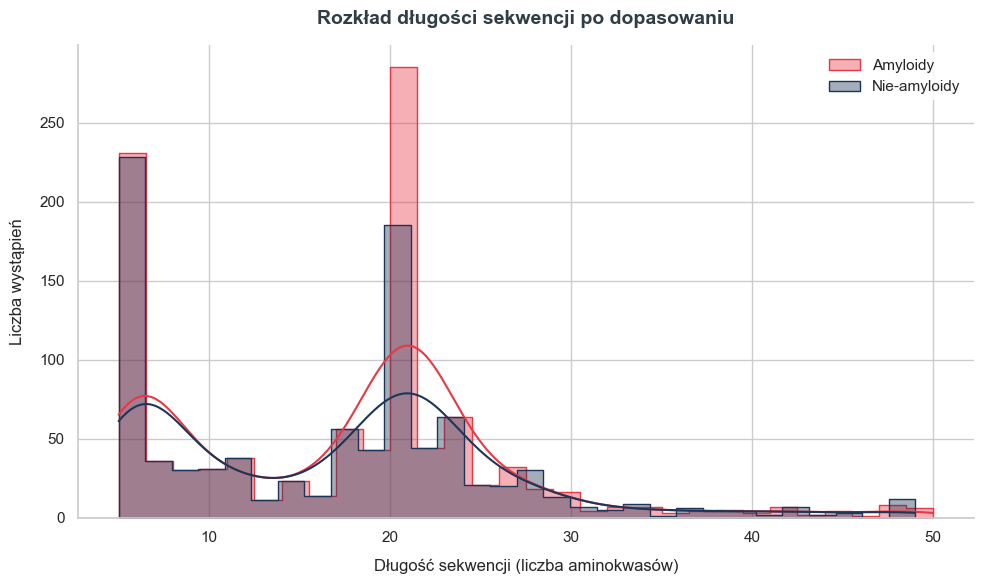

In [53]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df_amy,
    x='length',
    color='#E63946',
    label='Amyloidy',
    kde=True,
    alpha=0.4,
    bins=30,
    element="step"
)

sns.histplot(
    data=df_non_final,
    x='length',
    color='#1D3557',
    label='Nie-amyloidy',
    kde=True,
    alpha=0.4,
    bins=30,
    element="step"
)

plt.title("Rozkład długości sekwencji po dopasowaniu", fontsize=14, pad=15, fontweight='bold', color='#2F3E46')
plt.xlabel("Długość sekwencji (liczba aminokwasów)", fontsize=12, labelpad=10)
plt.ylabel("Liczba wystąpień", fontsize=12, labelpad=10)

plt.legend(frameon=True, facecolor='white', edgecolor='none', fontsize=11, loc='upper right')

sns.despine()

plt.tight_layout()
plt.savefig("./files/plots/length_distribution_sns.svg", format="svg", bbox_inches="tight")
plt.show()

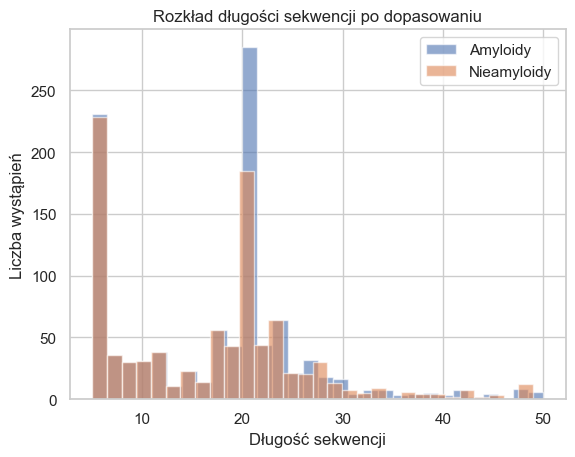

In [47]:
plt.hist(df_amy['length'], bins=30, alpha=0.6, label='Amyloidy')
plt.hist(df_non_final['length'], bins=30, alpha=0.6, label='Nieamyloidy')

plt.legend()
plt.xlabel("Długość sekwencji")
plt.ylabel("Liczba wystąpień")
plt.title("Rozkład długości sekwencji po dopasowaniu")

plt.savefig("./files/plots/length_distribution.svg", format="svg", bbox_inches="tight")
plt.show()

In [48]:
ks_stat, p_value = ks_2samp(df_amy['length'], df_non_final['length'])
print("KS statistic:", ks_stat)
print("p-value:", p_value)

if p_value < 0.05:
    print("The distributions are significantly different.")
else:
    print("The distributions are not significantly different.")

KS statistic: 0.05509944553639805
p-value: 0.09177069947864
The distributions are not significantly different.


## SHAP analysis

In [49]:
df_final.columns

Index(['id', 'sequence', 'length', 'polar_fraction', 'nonpolar_fraction',
       'acidic_fraction', 'basic_fraction', 'net_charge', 'hydrophobicity',
       'a3vSA', 'AAT', 'Na4vSS', 'THSA', 'nHS', 'TA'],
      dtype='object')

In [50]:
df_final = pd.concat([df_amy, df_non_final], ignore_index=True)

df_ml = df_final.copy() #class 0 and 1 -> non and amy

cols_to_drop = ['region']
df_ml = df_ml.drop(columns=[c for c in cols_to_drop if c in df_ml.columns])

y = df_ml['class']
X = df_ml.drop(columns=['class'])

print("X shape:", X.shape)
print("y distribution:\n", y.value_counts())

X shape: (2003, 3)
y distribution:
 class
1    1054
0     949
Name: count, dtype: int64


In [ ]:
df_ml = df_ml.drop_duplicates(subset=['id', 'sequence']).reset_index(drop=True)

df_ml['id'] = (
    df_ml['id'].astype(str) + '_' +
    df_ml.groupby('id').cumcount().astype(str)
)

df_ml['id'] = (
    df_ml['id']
    .astype(str)
    .str.strip()
    .str.replace(r'\s+', '', regex=True)
)

print("Rows:", len(df_ml))
print("Unique ids:", df_ml['id'].nunique())
print("Unique sequences:", df_ml['sequence'].nunique())

### Features

In [52]:
fasta_out = "files/df_ml_for_aggrescan.fasta"

valid_aas = set("ACDEFGHIKLMNPQRSTVWY")

skipped = []
written = 0

with open(fasta_out, "w") as f:
    for _, row in df_ml.iterrows():
        seq_id = str(row['id'])
        seq = str(row['sequence']).upper()

        if not set(seq).issubset(valid_aas):
            skipped.append(seq_id)
            continue

        f.write(f">{seq_id}\n")
        f.write(f"{seq}\n")
        written+=1

print(f"Skipped sequences: {len(skipped)}")
print(skipped)

print("Written sequences: ", written)

Skipped sequences: 2
['AMY1383_1_0', 'AMY1398_1_0']
Written sequences:  1963


In [53]:
agg_file = 'files/aggrescan_df_ml.txt'

agg_data = []
with open(agg_file) as f:
    for line in f:
        line = line.strip()
        if not line or line.startswith("#"):
            continue
        if not (line[0].isdigit() or line[0] == '-'):
            continue

        cols = line.split()
        if len(cols) < 13:
            continue

        agg_data.append({
            "id": cols[1].replace(">", ""),
            "a3vSA": float(cols[0]),
            "AAT": float(cols[5]),
            "Na4vSS": float(cols[7]),
            "THSA": float(cols[9]),
            "nHS": int(cols[11]),
            "TA": float(cols[12]),
        })

df_agg = pd.DataFrame(agg_data)
df_agg

,id,a3vSA,AAT,Na4vSS,THSA,nHS,TA
0,GI_171848907_PDB_2RNM_A__1_1_0,-0.457,0.190,-0.494,0.190,1,-9.478301
1,GI_342871650_GB_EGU74155_1_1_0,-0.160,2.140,-0.165,1.871,1,-2.956500
2,GI_342887385_GB_EGU86897_1_1_0,-0.256,1.438,-0.256,1.438,1,-3.895801
3,GI_347837243_EMB_CCD5181_1_1_0,-0.001,4.054,-0.008,4.054,2,0.459500
4,GI_475677570_GB_EMT74561_1_1_0,-0.436,0.570,-0.435,0.000,0,-8.256500
...,...,...,...,...,...,...,...
1958,Q2FS38,-0.163,6.539,-0.189,5.337,2,-7.608800
1959,P54429,0.019,11.900,-0.017,10.334,2,-0.171199
1960,P0CC18,-0.257,5.744,-0.306,3.330,1,-14.332602
1961,P0C6S4,-0.365,1.074,-0.364,0.000,0,-16.068802


In [54]:
def make_merge_id(id_):
    if not isinstance(id_, str):
        return id_

    id_ = id_.strip()

    # case UniProt
    if id_.startswith('sp|') or id_.startswith('tr|'):
        m = re.search(r'\|([A-Z0-9]{6,10})\|', id_)
        if m:
            return m.group(1)
    return id_

df_ml['merge_id'] = df_ml['id'].apply(make_merge_id)
df_ml

,id,sequence,length,class,merge_id
0,GI_171848907_PDB_2RNM_A__1_1_0,GRNSAKDIRTEERARVQLGNV,21,1,GI_171848907_PDB_2RNM_A__1_1_0
1,GI_342871650_GB_EGU74155_1_1_0,VRIYAKDIKSEEMARVRVGNE,21,1,GI_342871650_GB_EGU74155_1_1_0
2,GI_342887385_GB_EGU86897_1_1_0,GKNSAGRINGPGMVNIGNS,19,1,GI_342887385_GB_EGU86897_1_1_0
3,GI_347837243_EMB_CCD5181_1_1_0,HRIKIGKVTQASNAKAVIGVH,21,1,GI_347837243_EMB_CCD5181_1_1_0
4,GI_475677570_GB_EMT74561_1_1_0,VRNYASEIKGDEDAKVRLGND,21,1,GI_475677570_GB_EMT74561_1_1_0
...,...,...,...,...,...
1960,sp|Q2FS38|RL40_METHJ_0,MARFPEAEARLLNVKICMHCNARNPVRAVSCRKCGYVHLRPKNKDRKA,48,0,Q2FS38
1961,sp|P54429|YRKB_BACSU_0,MLLKNWPSRRIQRDKSKRAGIGGTNNRIPYTLLLCYVNVQKPFRIVDL,48,0,P54429
1962,sp|P0CC18|TXL1_LASPA_0,FFECTFECDIKKEGKPCKPKGCKCKDKDNKDHKKCSGGWRCKLKLCLKF,49,0,P0CC18
1963,sp|P0C6S4|VM2TO_ERIMA_0,QEEPCATGPCCRRCKFKRAGKVCRVARGDWNDDYCTGKSCDCPKNPWNG,49,0,P0C6S4


In [55]:
df_agg['merge_id'] = (
    df_agg['id']
    .astype(str)
    .str.replace(r'[>\s]', '', regex=True)
)

df_agg

,id,a3vSA,AAT,Na4vSS,THSA,nHS,TA,merge_id
0,GI_171848907_PDB_2RNM_A__1_1_0,-0.457,0.190,-0.494,0.190,1,-9.478301,GI_171848907_PDB_2RNM_A__1_1_0
1,GI_342871650_GB_EGU74155_1_1_0,-0.160,2.140,-0.165,1.871,1,-2.956500,GI_342871650_GB_EGU74155_1_1_0
2,GI_342887385_GB_EGU86897_1_1_0,-0.256,1.438,-0.256,1.438,1,-3.895801,GI_342887385_GB_EGU86897_1_1_0
3,GI_347837243_EMB_CCD5181_1_1_0,-0.001,4.054,-0.008,4.054,2,0.459500,GI_347837243_EMB_CCD5181_1_1_0
4,GI_475677570_GB_EMT74561_1_1_0,-0.436,0.570,-0.435,0.000,0,-8.256500,GI_475677570_GB_EMT74561_1_1_0
...,...,...,...,...,...,...,...,...
1958,Q2FS38,-0.163,6.539,-0.189,5.337,2,-7.608800,Q2FS38
1959,P54429,0.019,11.900,-0.017,10.334,2,-0.171199,P54429
1960,P0CC18,-0.257,5.744,-0.306,3.330,1,-14.332602,P0CC18
1961,P0C6S4,-0.365,1.074,-0.364,0.000,0,-16.068802,P0C6S4


In [56]:
df_ml_merged = df_ml.merge(
    df_agg.drop(columns=['id']),
    on='merge_id',
    how='left'
)
df_ml_merged = df_ml_merged.dropna()
print("Final dataframe:", df_ml_merged.shape)
df_ml_merged

Final dataframe: (1960, 11)


,id,sequence,length,class,merge_id,a3vSA,AAT,Na4vSS,THSA,nHS,TA
0,GI_171848907_PDB_2RNM_A__1_1_0,GRNSAKDIRTEERARVQLGNV,21,1,GI_171848907_PDB_2RNM_A__1_1_0,-0.457,0.190,-0.494,0.190,1.0,-9.478301
1,GI_342871650_GB_EGU74155_1_1_0,VRIYAKDIKSEEMARVRVGNE,21,1,GI_342871650_GB_EGU74155_1_1_0,-0.160,2.140,-0.165,1.871,1.0,-2.956500
2,GI_342887385_GB_EGU86897_1_1_0,GKNSAGRINGPGMVNIGNS,19,1,GI_342887385_GB_EGU86897_1_1_0,-0.256,1.438,-0.256,1.438,1.0,-3.895801
3,GI_347837243_EMB_CCD5181_1_1_0,HRIKIGKVTQASNAKAVIGVH,21,1,GI_347837243_EMB_CCD5181_1_1_0,-0.001,4.054,-0.008,4.054,2.0,0.459500
4,GI_475677570_GB_EMT74561_1_1_0,VRNYASEIKGDEDAKVRLGND,21,1,GI_475677570_GB_EMT74561_1_1_0,-0.436,0.570,-0.435,0.000,0.0,-8.256500
...,...,...,...,...,...,...,...,...,...,...,...
1960,sp|Q2FS38|RL40_METHJ_0,MARFPEAEARLLNVKICMHCNARNPVRAVSCRKCGYVHLRPKNKDRKA,48,0,Q2FS38,-0.163,6.539,-0.189,5.337,2.0,-7.608800
1961,sp|P54429|YRKB_BACSU_0,MLLKNWPSRRIQRDKSKRAGIGGTNNRIPYTLLLCYVNVQKPFRIVDL,48,0,P54429,0.019,11.900,-0.017,10.334,2.0,-0.171199
1962,sp|P0CC18|TXL1_LASPA_0,FFECTFECDIKKEGKPCKPKGCKCKDKDNKDHKKCSGGWRCKLKLCLKF,49,0,P0CC18,-0.257,5.744,-0.306,3.330,1.0,-14.332602
1963,sp|P0C6S4|VM2TO_ERIMA_0,QEEPCATGPCCRRCKFKRAGKVCRVARGDWNDDYCTGKSCDCPKNPWNG,49,0,P0C6S4,-0.365,1.074,-0.364,0.000,0.0,-16.068802


In [57]:
print((df_ml_merged['class'] == 0).sum())
print((df_ml_merged['class'] == 1).sum())

928
1032


In [58]:
df_ml_merged['net_charge'] = df_ml_merged['sequence'].apply(net_charge)
df_ml_merged['hydrophobicity'] = df_ml_merged['sequence'].apply(lambda s: sum(hydro_scale[a] for a in s)/len(s) if len(s)>0 else 0)

aa_groups = {
    "polar": "NQSTY",
    "nonpolar": "ACFGILMPVW",
    "acidic": "DE",
    "basic": "HKR",
}

def aa_fraction(seq, aas):
    return sum(seq.count(a) for a in aas) / len(seq) if len(seq) > 0 else 0

for group, letters in aa_groups.items():
    df_ml_merged[group+"_fraction"] = df_ml_merged['sequence'].apply(lambda s: aa_fraction(s, letters))

df_ml_merged['aromatic_fraction'] = (
    df_ml_merged['sequence'].apply(lambda s: sum(s.count(a) for a in "FYW") / len(s)))

beta_prop = {
    'A':0.83,'C':1.19,'D':0.54,'E':0.37,'F':1.38,'G':0.75,'H':0.87,'I':1.60,
    'K':0.74,'L':1.30,'M':1.05,'N':0.89,'P':0.55,'Q':1.10,'R':0.93,'S':0.75,
    'T':1.19,'V':1.70,'W':1.37,'Y':1.47
}

df_ml_merged['beta_propensity'] = df_ml_merged['sequence'].apply(
    lambda s: sum(beta_prop[a] for a in s) / len(s)
)

import math
from collections import Counter

def seq_entropy(seq):
    counts = Counter(seq)
    total = len(seq)
    return -sum(
        (c/total) * math.log2(c/total)
        for c in counts.values()
    )

df_ml_merged['seq_entropy'] = df_ml_merged['sequence'].apply(seq_entropy)

df_ml_merged['proline_fraction'] = (
    df_ml_merged['sequence'].apply(lambda s: s.count('P') / len(s))
)

df_ml_merged

,id,sequence,length,class,merge_id,a3vSA,AAT,Na4vSS,THSA,nHS,...,net_charge,hydrophobicity,polar_fraction,nonpolar_fraction,acidic_fraction,basic_fraction,aromatic_fraction,beta_propensity,seq_entropy,proline_fraction
0,GI_171848907_PDB_2RNM_A__1_1_0,GRNSAKDIRTEERARVQLGNV,21,1,GI_171848907_PDB_2RNM_A__1_1_0,-0.457,0.190,-0.494,0.190,1.0,...,2.0,-1.185714,0.238095,0.380952,0.142857,0.238095,0.000000,0.953333,3.535175,0.000000
1,GI_342871650_GB_EGU74155_1_1_0,VRIYAKDIKSEEMARVRVGNE,21,1,GI_342871650_GB_EGU74155_1_1_0,-0.160,2.140,-0.165,1.871,1.0,...,1.0,-0.676190,0.142857,0.428571,0.190476,0.238095,0.047619,0.990000,3.427333,0.000000
2,GI_342887385_GB_EGU86897_1_1_0,GKNSAGRINGPGMVNIGNS,19,1,GI_342887385_GB_EGU86897_1_1_0,-0.256,1.438,-0.256,1.438,1.0,...,2.0,-0.563158,0.315789,0.578947,0.000000,0.105263,0.000000,0.937368,3.005315,0.052632
3,GI_347837243_EMB_CCD5181_1_1_0,HRIKIGKVTQASNAKAVIGVH,21,1,GI_347837243_EMB_CCD5181_1_1_0,-0.001,4.054,-0.008,4.054,2.0,...,4.2,-0.019048,0.190476,0.523810,0.000000,0.285714,0.000000,1.081429,3.296148,0.000000
4,GI_475677570_GB_EMT74561_1_1_0,VRNYASEIKGDEDAKVRLGND,21,1,GI_475677570_GB_EMT74561_1_1_0,-0.436,0.570,-0.435,0.000,0.0,...,-1.0,-1.138095,0.190476,0.380952,0.238095,0.190476,0.047619,0.912381,3.499228,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1960,sp|Q2FS38|RL40_METHJ_0,MARFPEAEARLLNVKICMHCNARNPVRAVSCRKCGYVHLRPKNKDRKA,48,0,Q2FS38,-0.163,6.539,-0.189,5.337,2.0,...,9.2,-0.606250,0.125000,0.520833,0.062500,0.291667,0.041667,0.977708,3.787448,0.062500
1961,sp|P54429|YRKB_BACSU_0,MLLKNWPSRRIQRDKSKRAGIGGTNNRIPYTLLLCYVNVQKPFRIVDL,48,0,P54429,0.019,11.900,-0.017,10.334,2.0,...,8.0,-0.431250,0.250000,0.500000,0.041667,0.208333,0.083333,1.067083,3.933208,0.062500
1962,sp|P0CC18|TXL1_LASPA_0,FFECTFECDIKKEGKPCKPKGCKCKDKDNKDHKKCSGGWRCKLKLCLKF,49,0,P0CC18,-0.257,5.744,-0.306,3.330,1.0,...,8.1,-1.028571,0.061224,0.469388,0.142857,0.326531,0.102041,0.903469,3.312409,0.040816
1963,sp|P0C6S4|VM2TO_ERIMA_0,QEEPCATGPCCRRCKFKRAGKVCRVARGDWNDDYCTGKSCDCPKNPWNG,49,0,P0C6S4,-0.365,1.074,-0.364,0.000,0.0,...,4.0,-1.104082,0.163265,0.510204,0.122449,0.204082,0.081633,0.920408,3.730247,0.081633


In [59]:
df_ml_merged['id'] = df_ml_merged['id'].str.replace(r'_0$', '', regex=True)

### Train/Test split + scaling

In [60]:
y = df_ml_merged['class']

X = df_ml_merged.drop(columns=[
    'class',
    'sequence',
    'id'
], errors='ignore')


X_num = X.select_dtypes(include=['number'])

X_train, X_test, y_train, y_test = train_test_split(
    X_num, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [61]:
print(X_num)

      length  a3vSA     AAT  Na4vSS    THSA  nHS         TA  net_charge  \
0         21 -0.457   0.190  -0.494   0.190  1.0  -9.478301         2.0   
1         21 -0.160   2.140  -0.165   1.871  1.0  -2.956500         1.0   
2         19 -0.256   1.438  -0.256   1.438  1.0  -3.895801         2.0   
3         21 -0.001   4.054  -0.008   4.054  2.0   0.459500         4.2   
4         21 -0.436   0.570  -0.435   0.000  0.0  -8.256500        -1.0   
...      ...    ...     ...     ...     ...  ...        ...         ...   
1960      48 -0.163   6.539  -0.189   5.337  2.0  -7.608800         9.2   
1961      48  0.019  11.900  -0.017  10.334  2.0  -0.171199         8.0   
1962      49 -0.257   5.744  -0.306   3.330  1.0 -14.332602         8.1   
1963      49 -0.365   1.074  -0.364   0.000  0.0 -16.068802         4.0   
1964      49 -0.152   8.175  -0.184   6.052  2.0  -7.708199         7.1   

      hydrophobicity  polar_fraction  nonpolar_fraction  acidic_fraction  \
0          -1.185714   

In [62]:
X_num

,length,a3vSA,AAT,Na4vSS,THSA,nHS,TA,net_charge,hydrophobicity,polar_fraction,nonpolar_fraction,acidic_fraction,basic_fraction,aromatic_fraction,beta_propensity,seq_entropy,proline_fraction
0,21,-0.457,0.190,-0.494,0.190,1.0,-9.478301,2.0,-1.185714,0.238095,0.380952,0.142857,0.238095,0.000000,0.953333,3.535175,0.000000
1,21,-0.160,2.140,-0.165,1.871,1.0,-2.956500,1.0,-0.676190,0.142857,0.428571,0.190476,0.238095,0.047619,0.990000,3.427333,0.000000
2,19,-0.256,1.438,-0.256,1.438,1.0,-3.895801,2.0,-0.563158,0.315789,0.578947,0.000000,0.105263,0.000000,0.937368,3.005315,0.052632
3,21,-0.001,4.054,-0.008,4.054,2.0,0.459500,4.2,-0.019048,0.190476,0.523810,0.000000,0.285714,0.000000,1.081429,3.296148,0.000000
4,21,-0.436,0.570,-0.435,0.000,0.0,-8.256500,-1.0,-1.138095,0.190476,0.380952,0.238095,0.190476,0.047619,0.912381,3.499228,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1960,48,-0.163,6.539,-0.189,5.337,2.0,-7.608800,9.2,-0.606250,0.125000,0.520833,0.062500,0.291667,0.041667,0.977708,3.787448,0.062500
1961,48,0.019,11.900,-0.017,10.334,2.0,-0.171199,8.0,-0.431250,0.250000,0.500000,0.041667,0.208333,0.083333,1.067083,3.933208,0.062500
1962,49,-0.257,5.744,-0.306,3.330,1.0,-14.332602,8.1,-1.028571,0.061224,0.469388,0.142857,0.326531,0.102041,0.903469,3.312409,0.040816
1963,49,-0.365,1.074,-0.364,0.000,0.0,-16.068802,4.0,-1.104082,0.163265,0.510204,0.122449,0.204082,0.081633,0.920408,3.730247,0.081633


In [63]:
print(y_train.value_counts())
print(y_test.value_counts())

class
1    826
0    742
Name: count, dtype: int64
class
1    206
0    186
Name: count, dtype: int64


### Random Forest - base for the SHAP

In [64]:
model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_scaled, y_train)

,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [65]:
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
print("ROC AUC:", roc_auc_score(y_test, y_pred_proba))

ROC AUC: 0.793102098340119


In [66]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

logreg.fit(X_train_scaled, y_train)

y_pred_lr = logreg.predict_proba(X_test_scaled)[:, 1]
print("LR ROC AUC:", roc_auc_score(y_test, y_pred_lr))

LR ROC AUC: 0.7890698402756029


### SHAP

In [67]:
explainer = shap.TreeExplainer(model)
# SHAP values for class 1 (amy)
shap_values = explainer.shap_values(
    X_test_scaled,
    check_additivity=False
)

In [68]:
print(shap_values.shape)
print(shap_values[1].shape)
print(X_test_scaled.shape)

(392, 17, 2)
(17, 2)
(392, 17)


In [69]:
shap_vals_amy = shap_values[:, :, 1]
print(shap_vals_amy.shape)

(392, 17)


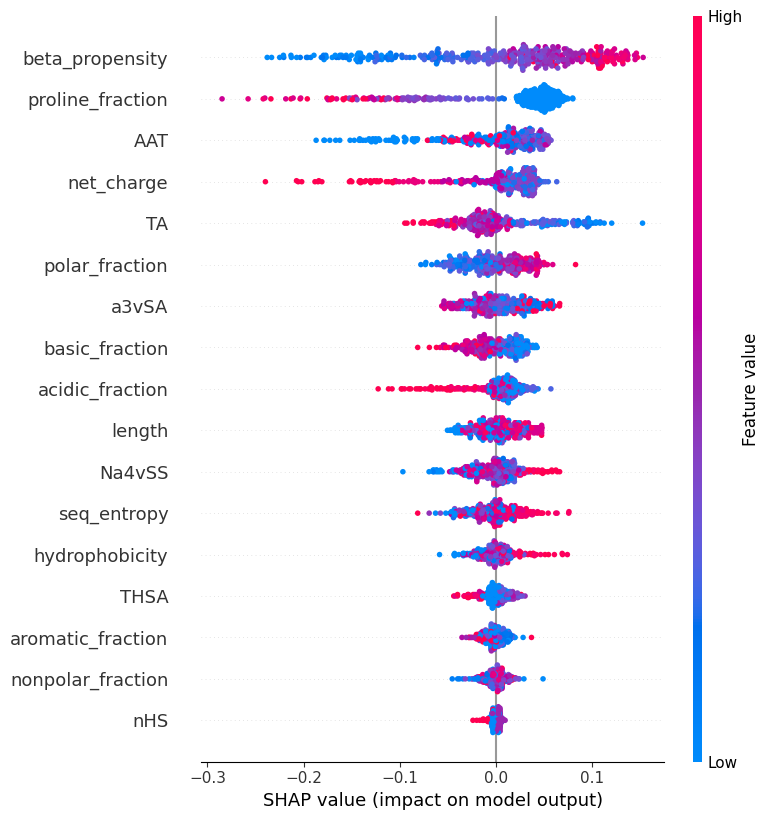

In [73]:
X_test_scaled_df = pd.DataFrame(
    X_test_scaled,
    columns=X_num.columns,
    index=X_test.index
)

plt.figure(figsize=(10, 14))
shap.summary_plot(
    shap_vals_amy,
    X_test_scaled_df,
    max_display=20,
    show=False
)
plt.tight_layout()

plt.savefig("./files/plots/shap_summary.svg", format="svg", bbox_inches="tight")


plt.show()

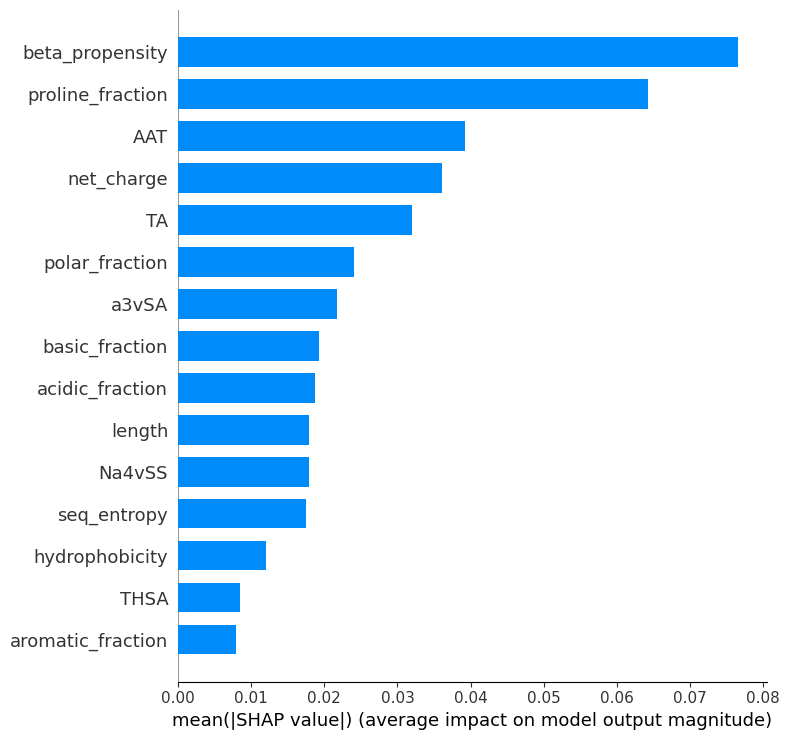

In [71]:
shap.summary_plot(
    shap_vals_amy,
    X_test,
    plot_type="bar",
    max_display=15
)

In [72]:
mean_abs_shap = np.abs(shap_vals_amy).mean(axis=0)

feature_importance = pd.DataFrame({
    "feature": X_test.columns,
    "mean_abs_shap": mean_abs_shap
}).sort_values(by="mean_abs_shap", ascending=False)

print(feature_importance)

feature_importance["cumulative"] = (
    feature_importance["mean_abs_shap"].cumsum() /
    feature_importance["mean_abs_shap"].sum()
)

selected = feature_importance[
    feature_importance["cumulative"] <= 0.7
]["feature"].tolist()

print(selected)

              feature  mean_abs_shap
14    beta_propensity       0.076609
16   proline_fraction       0.064233
2                 AAT       0.039230
7          net_charge       0.036081
6                  TA       0.031960
9      polar_fraction       0.024073
1               a3vSA       0.021727
12     basic_fraction       0.019300
11    acidic_fraction       0.018678
0              length       0.017908
3              Na4vSS       0.017886
15        seq_entropy       0.017476
8      hydrophobicity       0.012094
4                THSA       0.008520
13  aromatic_fraction       0.007869
10  nonpolar_fraction       0.007493
5                 nHS       0.003081
['beta_propensity', 'proline_fraction', 'AAT', 'net_charge', 'TA', 'polar_fraction', 'a3vSA']


# Sequences quality/Filtering

## Feature extraction

In [74]:
hydro_scale = {
    'A':1.8,'C':2.5,'D':-3.5,'E':-3.5,'F':2.8,'G':-0.4,'H':-3.2,'I':4.5,
    'K':-3.9,'L':3.8,'M':1.9,'N':-3.5,'P':-1.6,'Q':-3.5,'R':-4.5,'S':-0.8,
    'T':-0.7,'V':4.2,'W':-0.9,'Y':-1.3
}

beta_prop = {
    'A':0.83,'C':1.19,'D':0.54,'E':0.37,'F':1.38,'G':0.75,'H':0.87,'I':1.60,
    'K':0.74,'L':1.30,'M':1.05,'N':0.89,'P':0.55,'Q':1.10,'R':0.93,'S':0.75,
    'T':1.19,'V':1.70,'W':1.37,'Y':1.47
}

valid_aas = set("ACDEFGHIKLMNPQRSTVWY")

def clean_sequence(seq):
    seq = seq.upper().strip()
    seq = "".join([a for a in seq if a in valid_aas])
    return seq

def seq_entropy(seq):
    from collections import Counter
    c = Counter(seq)
    L = len(seq)
    return -sum((v/L)*np.log2(v/L) for v in c.values())

def net_charge(seq):
    return seq.count('K') + seq.count('R') - seq.count('D') - seq.count('E') + 0.1*seq.count('H')

def compute_features(seq):
    seq = clean_sequence(seq)
    seq = seq.upper().strip()
    L = len(seq)

    pa = ProteinAnalysis(seq)
    iep = iep = IEP(seq).pi()

    return {
        "length": L,
        "entropy": seq_entropy(seq),
        "hydrophobicity": sum(hydro_scale[a] for a in seq) / L,
        "net_charge": net_charge(seq),
        "beta_propensity": sum(beta_prop[a] for a in seq) / L,
        "aromatic_fraction": sum(seq.count(a) for a in "FYW") / L,
        "proline_fraction": seq.count("P") / L,
        "pI": iep,
        "gravy": pa.gravy(),
        "instability_index": pa.instability_index()
    }

def add_features(df, seq_col="sequence"):
    feats = df[seq_col].apply(compute_features)
    return pd.concat([df.reset_index(drop=True), pd.DataFrame(list(feats))], axis=1)

## Scoring against reference amyloids

In [75]:
def score_vs_amyloids(df_gen_feat, df_amy_ref_feat, feature_cols, z_cutoff=4.0):

    df_scored = df_gen_feat.copy()

    z_abs_vals = []

    for c in feature_cols:
        mu = df_amy_ref_feat[c].mean()
        sd = df_amy_ref_feat[c].std()

        if sd == 0 or np.isnan(sd):
            z = (df_scored[c] - mu) * 0.0
        else:
            z = (df_scored[c] - mu) / sd

        df_scored[c + "_z"] = z
        z_abs_vals.append(z.abs())

    z_abs_stack = np.vstack([z.values for z in z_abs_vals])

    df_scored["amyloid_likeness_score"] = z_abs_stack.mean(axis=0)
    df_scored["flag_outlier"] = (z_abs_stack > z_cutoff).any(axis=0)

    return df_scored

## Checking real sequences

In [76]:
df_amy_ref_feat = add_features(df_amy, seq_col="sequence")

df_gen_feat = add_features(df_amy, seq_col="sequence")

feature_cols = [
    "length", "entropy", "hydrophobicity", "net_charge",
    "beta_propensity", "aromatic_fraction", "proline_fraction",
    "pI", "gravy", "instability_index"
]

df_gen_feat = df_gen_feat.loc[:, ~df_gen_feat.columns.duplicated()]
df_amy_ref_feat = df_amy_ref_feat.loc[:, ~df_amy_ref_feat.columns.duplicated()]

df_gen_scored = score_vs_amyloids(df_gen_feat, df_amy_ref_feat, feature_cols)

print(df_gen_scored[["amyloid_likeness_score", "flag_outlier"]].describe())

       amyloid_likeness_score
count             1034.000000
mean                 0.757992
std                  0.288506
min                  0.225494
25%                  0.552212
50%                  0.719023
75%                  0.896526
max                  2.640508


## 'Good" sequences filtering

In [77]:
df_gen_good = df_gen_scored[
    (df_gen_scored["flag_outlier"] == False) &
    (df_gen_scored["amyloid_likeness_score"] < 2.5)
].copy()

df_gen_good['id'] = df_gen_good['id'].str.replace(r'\s+_', '_', regex=True)

print("Keept:", len(df_gen_good), "from", len(df_gen_scored))

Keept: 1008 from 1034


## File to AlphaFold

In [78]:
def write_fasta(df, filename, seq_col="sequence", id_col="id"):
    with open(filename, "w") as f:
        for i, row in df.iterrows():
            sid = row.get(id_col, f"gen_{i}")
            seq = row[seq_col]
            f.write(f">{sid}\n{seq}\n")

write_fasta(df_gen_good, "files/df_gen_scored.csv")

# Final result

In [79]:
df_non_amyloid = df_ml_merged[df_ml_merged['class'] == 0]

df_ml_good = df_ml_merged[df_ml_merged['id'].isin(df_gen_good['id'])].copy()

df_ml_final = pd.concat([df_ml_good, df_non_amyloid], ignore_index=True).drop_duplicates(subset='id').reset_index(drop=True)

output_file = "files/df_ml_good_with_features.csv"
df_ml_final.to_csv(output_file, index=False)

print(df_ml_final)

                                id  \
0     GI_171848907_PDB_2RNM_A__1_1   
1     GI_342871650_GB_EGU74155_1_1   
2     GI_342887385_GB_EGU86897_1_1   
3     GI_347837243_EMB_CCD5181_1_1   
4     GI_475677570_GB_EMT74561_1_1   
...                            ...   
1929          sp|Q2FS38|RL40_METHJ   
1930          sp|P54429|YRKB_BACSU   
1931          sp|P0CC18|TXL1_LASPA   
1932         sp|P0C6S4|VM2TO_ERIMA   
1933          sp|B1MZH9|RL33_LEUCK   

                                               sequence  length  class  \
0                                 GRNSAKDIRTEERARVQLGNV      21      1   
1                                 VRIYAKDIKSEEMARVRVGNE      21      1   
2                                   GKNSAGRINGPGMVNIGNS      19      1   
3                                 HRIKIGKVTQASNAKAVIGVH      21      1   
4                                 VRNYASEIKGDEDAKVRLGND      21      1   
...                                                 ...     ...    ...   
1929   MARFPEAEARLLNVKICM

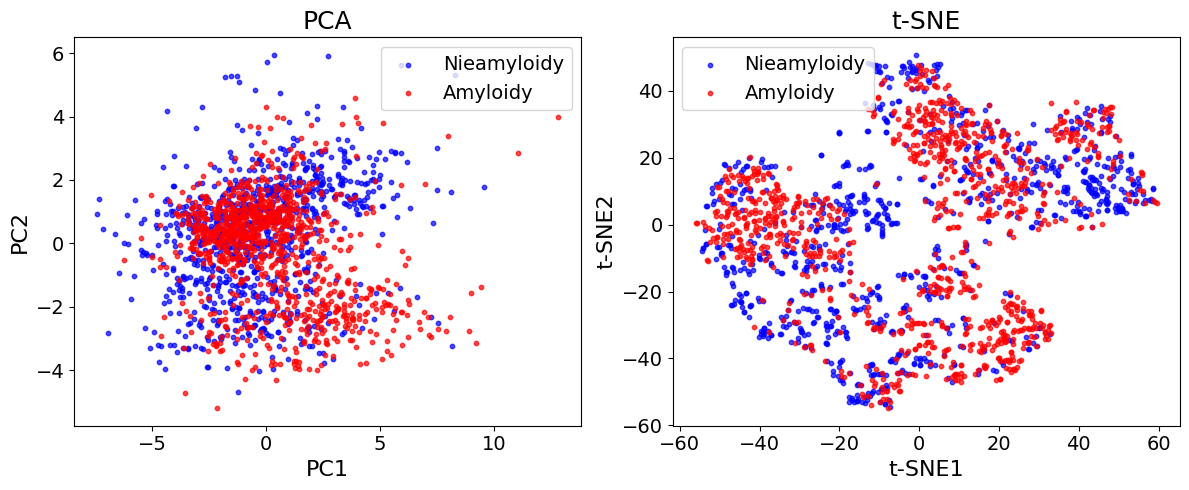

In [98]:
# standaryzacja
X = df_ml_final.drop(columns=[
    'class', 'sequence', 'id'
], errors='ignore')

y = df_ml_final['class']

# tylko numeryczne
X_num = X.select_dtypes(include=['number'])
X_scaled = StandardScaler().fit_transform(X_num)

# PCA (2D)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# t-SNE (często lepiej działa po PCA)
X_tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    init="pca",
    random_state=42
).fit_transform(X_scaled)

y_np = np.array(y)

# wykres
labels_map = {
    1: "Amyloidy",
    0: "Nieamyloidy"
}

colors = {
    1: "red",
    0: "blue"
}

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

for cls in [0, 1]:
    idx = (y_np == cls)

    ax[0].scatter(
        X_pca[idx, 0],
        X_pca[idx, 1],
        c=colors[cls],
        label=labels_map[cls],
        s=10,
        alpha=0.7
    )

    ax[1].scatter(
        X_tsne[idx, 0],
        X_tsne[idx, 1],
        c=colors[cls],
        label=labels_map[cls],
        s=10,
        alpha=0.7
    )

ax[0].set_title("PCA", fontsize=18)
ax[0].set_xlabel("PC1", fontsize=16)
ax[0].set_ylabel("PC2", fontsize=16)
ax[0].tick_params(axis='both', labelsize=14)
ax[0].legend(fontsize=14)

# --- t-SNE ---
ax[1].set_title("t-SNE", fontsize=18)
ax[1].set_xlabel("t-SNE1", fontsize=16)
ax[1].set_ylabel("t-SNE2", fontsize=16)
ax[1].tick_params(axis='both', labelsize=14)
ax[1].legend(fontsize=14)

plt.tight_layout()

plt.savefig("./files/plots/pca_tsne.svg", format="svg", bbox_inches="tight")

plt.show()

In [96]:
df_ml_final.describe()

,length,class,a3vSA,AAT,Na4vSS,THSA,nHS,TA,net_charge,hydrophobicity,polar_fraction,nonpolar_fraction,acidic_fraction,basic_fraction,aromatic_fraction,beta_propensity,seq_entropy,proline_fraction
count,1934.000000,1934.000000,1934.000000,1934.000000,1934.000000,1934.000000,1934.000000,1934.000000,1934.000000,1934.000000,1934.000000,1934.000000,1934.000000,1934.000000,1934.000000,1934.000000,1934.000000,1934.000000
mean,16.693899,0.520165,-0.003633,2.680868,-0.088546,1.989448,0.630300,-1.182478,0.192503,-0.152300,0.287820,0.511212,0.088195,0.112774,0.090459,1.038223,2.937598,0.023052
std,8.557852,0.499722,0.382876,2.663645,0.349713,2.704040,0.687131,4.421522,1.931952,1.002954,0.166744,0.164697,0.087229,0.092375,0.098771,0.119786,0.594311,0.046726
min,5.000000,0.000000,-1.320000,0.000000,-1.320000,0.000000,0.000000,-25.227301,-8.000000,-3.728571,0.000000,0.000000,0.000000,0.000000,0.000000,0.571667,0.650022,0.000000
25%,7.000000,0.000000,-0.233000,0.712000,-0.282750,0.000000,0.000000,-3.809225,-1.000000,-0.732500,0.166667,0.411765,0.000000,0.032814,0.000000,0.969487,2.521641,0.000000
50%,19.000000,1.000000,-0.052500,2.020000,-0.117000,0.960000,1.000000,-1.211050,0.000000,-0.225543,0.277778,0.500000,0.080541,0.106203,0.058824,1.026190,3.121339,0.000000
75%,21.000000,1.000000,0.194000,3.905000,0.101250,3.329500,1.000000,1.566150,1.000000,0.400000,0.363636,0.608696,0.142857,0.166667,0.142857,1.089938,3.403989,0.041667
max,49.000000,1.000000,1.630000,27.328000,1.258000,27.328000,4.000000,26.039400,16.000000,3.500000,1.000000,1.000000,0.571429,0.680000,0.500000,1.511667,4.006198,0.428571
